# Imports and project paths

In [3]:
from pathlib import Path
import re
import json
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 100)

# Adjust this if your notebook is not in the project root.
PROJECT_ROOT = Path(".").resolve()

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
RAW_CTD_DIR = RAW_DIR / "ctd"
RAW_META_DIR = RAW_DIR / "meta"

NORMALIZED_DIR = DATA_DIR / "normalized"
SERVING_DIR = DATA_DIR / "serving"

NORMALIZED_DIR.mkdir(parents=True, exist_ok=True)
SERVING_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_CTD_DIR :", RAW_CTD_DIR)
print("RAW_META_DIR:", RAW_META_DIR)
print("NORMALIZED  :", NORMALIZED_DIR)
print("SERVING     :", SERVING_DIR)

PROJECT_ROOT: /Users/jaronchai/PycharmProjects/anemone-chat/notebooks
RAW_CTD_DIR : /Users/jaronchai/PycharmProjects/anemone-chat/notebooks/data/raw/ctd
RAW_META_DIR: /Users/jaronchai/PycharmProjects/anemone-chat/notebooks/data/raw/meta
NORMALIZED  : /Users/jaronchai/PycharmProjects/anemone-chat/notebooks/data/normalized
SERVING     : /Users/jaronchai/PycharmProjects/anemone-chat/notebooks/data/serving


# Inventory the raw files & Helpers

In [4]:
def inventory_dir(path: Path) -> pd.DataFrame:
    rows = []
    for p in sorted(path.glob("*")):
        if p.is_file():
            rows.append({
                "name": p.name,
                "path": str(p),
                "size_bytes": p.stat().st_size,
                "suffix": p.suffix.lower(),
            })
    return pd.DataFrame(rows)

ctd_inventory = inventory_dir(RAW_CTD_DIR)
meta_inventory = inventory_dir(RAW_META_DIR)

print("CTD files")
display(ctd_inventory)

print("META files")
display(meta_inventory)

CTD files


,name,path,size_bytes,suffix
0,CTD_Onagawa.tsv,/Users/jaronchai/PycharmProjects/anemone-chat/...,1242925,.tsv


META files


,name,path,size_bytes,suffix
0,01.read_summary_gt1kb.tsv,/Users/jaronchai/PycharmProjects/anemone-chat/...,5330,.tsv
1,03.coverage.log.tsv,/Users/jaronchai/PycharmProjects/anemone-chat/...,165,.tsv
2,Kraken.genus-group.tsv,/Users/jaronchai/PycharmProjects/anemone-chat/...,27479,.tsv
3,Kraken.genus-sample.tsv,/Users/jaronchai/PycharmProjects/anemone-chat/...,693529,.tsv
4,Kraken.genus-sample.txt,/Users/jaronchai/PycharmProjects/anemone-chat/...,693529,.txt
5,Kraken.upper_group-sample.txt,/Users/jaronchai/PycharmProjects/anemone-chat/...,56740,.txt
6,MetaEuk.genus-sample.tsv,/Users/jaronchai/PycharmProjects/anemone-chat/...,685787,.tsv
7,genus-group.tsv,/Users/jaronchai/PycharmProjects/anemone-chat/...,3972467,.tsv
8,gn.consistency.tsv,/Users/jaronchai/PycharmProjects/anemone-chat/...,9626,.tsv
9,km.consistency.tsv,/Users/jaronchai/PycharmProjects/anemone-chat/...,29158343,.tsv


In [5]:
SAMPLE_ID_RE = re.compile(
    r"^(?P<sample_id>\d{4}-\d{2}-[OIM]-[A-Za-z0-9]+)(?:\.(?P<replicate>\d+))?$"
)

def parse_sample_replicate(value: str) -> dict:
    """
    Parse values like:
      2024-06-O-s4
      2024-06-O-s4.1
      2025-03-I-hm.2
    """
    s = str(value).strip()
    m = SAMPLE_ID_RE.match(s)
    if not m:
        return {
            "sample_replicate": s,
            "sample_id": pd.NA,
            "replicate_no": pd.NA,
            "sample_year_month": pd.NA,
            "bay": pd.NA,
            "station_code": pd.NA,
        }

    sample_id = m.group("sample_id")
    replicate_no = m.group("replicate")

    parts = sample_id.split("-")
    year_month = f"{parts[0]}-{parts[1]}"
    bay = parts[2]
    station_code = parts[3]

    return {
        "sample_replicate": s,
        "sample_id": sample_id,
        "replicate_no": int(replicate_no) if replicate_no is not None else 1,
        "sample_year_month": year_month,
        "bay": bay,
        "station_code": station_code,
    }

def read_tsv_no_header(path: Path, columns: list[str]) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t", header=None)
    if df.shape[1] != len(columns):
        raise ValueError(
            f"{path.name}: expected {len(columns)} cols, got {df.shape[1]}"
        )
    df.columns = columns
    return df

def read_tsv_with_header(path: Path) -> pd.DataFrame:
    return pd.read_csv(path, sep="\t")

def add_sample_parsed_columns(df: pd.DataFrame, source_col: str) -> pd.DataFrame:
    parsed = df[source_col].apply(parse_sample_replicate).apply(pd.Series)
    out = df.copy()
    for c in parsed.columns:
        out[c] = parsed[c]
    return out

def print_df_info(name: str, df: pd.DataFrame, n: int = 3) -> None:
    print(f"\n{name}")
    print("=" * len(name))
    print("shape:", df.shape)
    print("columns:", list(df.columns))
    display(df.head(n))

In [6]:
FILES = {
    "ctd": RAW_CTD_DIR / "CTD_Onagawa.tsv",
    "runid": RAW_META_DIR / "runid.tsv",
    "read_summary": RAW_META_DIR / "01.read_summary_gt1kb.tsv",
    "coverage_log": RAW_META_DIR / "03.coverage.log.tsv",
    "kraken_genus_sample_tsv": RAW_META_DIR / "Kraken.genus-sample.tsv",
    "kraken_genus_sample_txt": RAW_META_DIR / "Kraken.genus-sample.txt",
    "kraken_upper_group_sample": RAW_META_DIR / "Kraken.upper_group-sample.txt",
    "kraken_genus_group": RAW_META_DIR / "Kraken.genus-group.tsv",
    "metaeuk_genus_sample": RAW_META_DIR / "MetaEuk.genus-sample.tsv",
    "genus_group": RAW_META_DIR / "genus-group.tsv",
    "gn_consistency": RAW_META_DIR / "gn.consistency.tsv",
    "km_consistency": RAW_META_DIR / "km.consistency.tsv",
}

for key, path in FILES.items():
    print(f"{key:28s} -> {'OK' if path.exists() else 'MISSING'} | {path}")

ctd                          -> OK | /Users/jaronchai/PycharmProjects/anemone-chat/notebooks/data/raw/ctd/CTD_Onagawa.tsv
runid                        -> OK | /Users/jaronchai/PycharmProjects/anemone-chat/notebooks/data/raw/meta/runid.tsv
read_summary                 -> OK | /Users/jaronchai/PycharmProjects/anemone-chat/notebooks/data/raw/meta/01.read_summary_gt1kb.tsv
coverage_log                 -> OK | /Users/jaronchai/PycharmProjects/anemone-chat/notebooks/data/raw/meta/03.coverage.log.tsv
kraken_genus_sample_tsv      -> OK | /Users/jaronchai/PycharmProjects/anemone-chat/notebooks/data/raw/meta/Kraken.genus-sample.tsv
kraken_genus_sample_txt      -> OK | /Users/jaronchai/PycharmProjects/anemone-chat/notebooks/data/raw/meta/Kraken.genus-sample.txt
kraken_upper_group_sample    -> OK | /Users/jaronchai/PycharmProjects/anemone-chat/notebooks/data/raw/meta/Kraken.upper_group-sample.txt
kraken_genus_group           -> OK | /Users/jaronchai/PycharmProjects/anemone-chat/notebooks/data/raw/

# Load the run mapping and read summary tables

In [7]:
runid = read_tsv_no_header(
    FILES["runid"],
    columns=["run_id", "sample_replicate", "run_date"]
)

read_summary = read_tsv_no_header(
    FILES["read_summary"],
    columns=[
        "sample_replicate",
        "n_reads_gt1kb",
        "bases_gt1kb",
        "n_reads_gt10kb",
        "bases_gt10kb",
    ]
)

runid["run_date"] = pd.to_datetime(runid["run_date"], errors="coerce")

numeric_cols = ["n_reads_gt1kb", "bases_gt1kb", "n_reads_gt10kb", "bases_gt10kb"]
for c in numeric_cols:
    read_summary[c] = pd.to_numeric(read_summary[c], errors="coerce")

runid = add_sample_parsed_columns(runid, "sample_replicate")
read_summary = add_sample_parsed_columns(read_summary, "sample_replicate")

print_df_info("runid", runid)
print_df_info("read_summary", read_summary)

print("runid unique sample_replicate:", runid["sample_replicate"].nunique())
print("read_summary unique sample_replicate:", read_summary["sample_replicate"].nunique())


runid
=====
shape: (106, 8)
columns: ['run_id', 'sample_replicate', 'run_date', 'sample_id', 'replicate_no', 'sample_year_month', 'bay', 'station_code']


,run_id,sample_replicate,run_date,sample_id,replicate_no,sample_year_month,bay,station_code
0,r0001,2024-06-M-s0.1,2024-06-18,2024-06-M-s0,1,2024-06,M,s0
1,r0002,2024-06-M-s0.2,2024-06-18,2024-06-M-s0,2,2024-06,M,s0
2,r0003,2024-07-O-s1.1,2024-07-03,2024-07-O-s1,1,2024-07,O,s1



read_summary
shape: (106, 10)
columns: ['sample_replicate', 'n_reads_gt1kb', 'bases_gt1kb', 'n_reads_gt10kb', 'bases_gt10kb', 'sample_id', 'replicate_no', 'sample_year_month', 'bay', 'station_code']


,sample_replicate,n_reads_gt1kb,bases_gt1kb,n_reads_gt10kb,bases_gt10kb,sample_id,replicate_no,sample_year_month,bay,station_code
0,2024-04-O-s0.1,1655799,6997860108,94581,1727575022,2024-04-O-s0,1,2024-04,O,s0
1,2024-04-O-s0.2,2595405,9951765004,126092,2146784790,2024-04-O-s0,2,2024-04,O,s0
2,2024-04-O-s1.1,578918,2250572465,28590,446242843,2024-04-O-s1,1,2024-04,O,s1


runid unique sample_replicate: 106
read_summary unique sample_replicate: 106


# join run mapping to read summary

In [8]:
run_qc = runid.merge(
    read_summary.drop(columns=["sample_year_month", "bay", "station_code", "replicate_no", "sample_id"]),
    on="sample_replicate",
    how="left",
    validate="one_to_one",
)

print_df_info("run_qc", run_qc)

missing_qc = run_qc[run_qc["n_reads_gt1kb"].isna()]
print("Rows with missing QC after join:", len(missing_qc))
if len(missing_qc):
    display(missing_qc)

sample_qc = (
    run_qc.groupby("sample_id", dropna=False)
    .agg(
        n_runs=("run_id", "nunique"),
        first_run_date=("run_date", "min"),
        last_run_date=("run_date", "max"),
        sum_reads_gt1kb=("n_reads_gt1kb", "sum"),
        sum_bases_gt1kb=("bases_gt1kb", "sum"),
        sum_reads_gt10kb=("n_reads_gt10kb", "sum"),
        sum_bases_gt10kb=("bases_gt10kb", "sum"),
    )
    .reset_index()
)

print_df_info("sample_qc", sample_qc)


run_qc
shape: (106, 12)
columns: ['run_id', 'sample_replicate', 'run_date', 'sample_id', 'replicate_no', 'sample_year_month', 'bay', 'station_code', 'n_reads_gt1kb', 'bases_gt1kb', 'n_reads_gt10kb', 'bases_gt10kb']


,run_id,sample_replicate,run_date,sample_id,replicate_no,sample_year_month,bay,station_code,n_reads_gt1kb,bases_gt1kb,n_reads_gt10kb,bases_gt10kb
0,r0001,2024-06-M-s0.1,2024-06-18,2024-06-M-s0,1,2024-06,M,s0,2265083,9019259542,136162,2414893649
1,r0002,2024-06-M-s0.2,2024-06-18,2024-06-M-s0,2,2024-06,M,s0,2572561,9513080670,118699,2105080116
2,r0003,2024-07-O-s1.1,2024-07-03,2024-07-O-s1,1,2024-07,O,s1,139685,407257287,2271,34159231


Rows with missing QC after join: 0

sample_qc
shape: (82, 8)
columns: ['sample_id', 'n_runs', 'first_run_date', 'last_run_date', 'sum_reads_gt1kb', 'sum_bases_gt1kb', 'sum_reads_gt10kb', 'sum_bases_gt10kb']


,sample_id,n_runs,first_run_date,last_run_date,sum_reads_gt1kb,sum_bases_gt1kb,sum_reads_gt10kb,sum_bases_gt10kb
0,2024-04-O-s0,2,2024-04-01,2024-04-01,4251204,16949625112,220673,3874359812
1,2024-04-O-s1,1,2024-04-22,2024-04-22,578918,2250572465,28590,446242843
2,2024-04-O-s4,1,2024-04-22,2024-04-22,1310912,3341605588,12246,176937584


# Inspect CTD

In [9]:
ctd = read_tsv_with_header(FILES["ctd"])

# Standardize a few likely column names if present.
ctd.columns = [str(c).strip() for c in ctd.columns]

print_df_info("ctd_raw", ctd, n=5)

print("Null counts:")
display(ctd.isna().sum().sort_values(ascending=False).head(20))


ctd_raw
shape: (10955, 18)
columns: ['date', 'label', 'depth', 'Chl-Flu', 'temperature', 'salinity', 'sigmaT', 'Chl-a', 'EC', 'DO', 'voltage', 'density', 'turbidity', 'DO_mgL', 'EC25', 'ORP', 'pH', 'PAR']


,date,label,depth,Chl-Flu,temperature,salinity,sigmaT,Chl-a,EC,DO,voltage,density,turbidity,DO_mgL,EC25,ORP,pH,PAR
0,2024-01-18,2024-01-O-s1,0.0,0.78,11.868,34.011,25.846,0.78,38.860,111.24,8.23,1025.846,0.19,9.715,54648.362,NaN,NaN,NaN
1,2024-01-18,2024-01-O-s1,0.5,0.74,11.919,34.026,25.848,0.74,38.924,111.09,8.16,1025.850,0.24,9.682,54652.343,NaN,NaN,NaN
2,2024-01-18,2024-01-O-s1,1.0,0.72,11.921,34.047,25.864,0.72,38.948,111.13,8.16,1025.869,0.20,9.682,54682.230,NaN,NaN,NaN
3,2024-01-18,2024-01-O-s1,1.5,0.86,11.937,34.038,25.854,0.86,38.953,111.17,8.16,1025.861,0.21,9.686,54662.861,NaN,NaN,NaN
4,2024-01-18,2024-01-O-s1,2.0,0.93,11.940,34.034,25.850,0.93,38.953,111.13,8.17,1025.859,0.21,9.678,54656.145,NaN,NaN,NaN


Null counts:


PAR            10955
pH             10955
ORP            10955
label              0
EC25               0
DO_mgL             0
turbidity          0
density            0
voltage            0
date               0
EC                 0
Chl-a              0
sigmaT             0
salinity           0
temperature        0
Chl-Flu            0
depth              0
DO                 0
dtype: int64

# Normalize CTD

In [10]:
ctd_norm = ctd.copy()

# Expected key columns from your file inspection.
# Keep this defensive in case the exact capitalization differs.
col_map = {c.lower(): c for c in ctd_norm.columns}

def find_col(name_options):
    for opt in name_options:
        if opt.lower() in col_map:
            return col_map[opt.lower()]
    return None

label_col = find_col(["label"])
date_col = find_col(["date"])
depth_col = find_col(["depth", "depth(m)", "depth_m"])

if label_col is None:
    raise ValueError("Could not find CTD label column.")
if date_col is None:
    raise ValueError("Could not find CTD date column.")
if depth_col is None:
    raise ValueError("Could not find CTD depth column.")

ctd_norm = ctd_norm.rename(columns={
    label_col: "sample_id",
    date_col: "ctd_date",
    depth_col: "depth_m",
})

ctd_norm["ctd_date"] = pd.to_datetime(ctd_norm["ctd_date"], errors="coerce")
ctd_norm["depth_m"] = pd.to_numeric(ctd_norm["depth_m"], errors="coerce")

# Convert all non-key columns to numeric where possible, but do not force sample_id/date.
for c in ctd_norm.columns:
    if c not in {"sample_id", "ctd_date"}:
        ctd_norm[c] = pd.to_numeric(ctd_norm[c], errors="ignore")

print_df_info("ctd_norm", ctd_norm, n=5)

print("Unique CTD labels:", ctd_norm["sample_id"].nunique())
print("CTD date range:", ctd_norm["ctd_date"].min(), "to", ctd_norm["ctd_date"].max())
print("Depth range:", ctd_norm["depth_m"].min(), "to", ctd_norm["depth_m"].max())


ctd_norm
shape: (10955, 18)
columns: ['ctd_date', 'sample_id', 'depth_m', 'Chl-Flu', 'temperature', 'salinity', 'sigmaT', 'Chl-a', 'EC', 'DO', 'voltage', 'density', 'turbidity', 'DO_mgL', 'EC25', 'ORP', 'pH', 'PAR']


/var/folders/m3/t697fcxs4h9062q_kmbgyplr0000gn/T/ipykernel_28991/4050996123.py:36: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  ctd_norm[c] = pd.to_numeric(ctd_norm[c], errors="ignore")


,ctd_date,sample_id,depth_m,Chl-Flu,temperature,salinity,sigmaT,Chl-a,EC,DO,voltage,density,turbidity,DO_mgL,EC25,ORP,pH,PAR
0,2024-01-18,2024-01-O-s1,0.0,0.78,11.868,34.011,25.846,0.78,38.860,111.24,8.23,1025.846,0.19,9.715,54648.362,NaN,NaN,NaN
1,2024-01-18,2024-01-O-s1,0.5,0.74,11.919,34.026,25.848,0.74,38.924,111.09,8.16,1025.850,0.24,9.682,54652.343,NaN,NaN,NaN
2,2024-01-18,2024-01-O-s1,1.0,0.72,11.921,34.047,25.864,0.72,38.948,111.13,8.16,1025.869,0.20,9.682,54682.230,NaN,NaN,NaN
3,2024-01-18,2024-01-O-s1,1.5,0.86,11.937,34.038,25.854,0.86,38.953,111.17,8.16,1025.861,0.21,9.686,54662.861,NaN,NaN,NaN
4,2024-01-18,2024-01-O-s1,2.0,0.93,11.940,34.034,25.850,0.93,38.953,111.13,8.17,1025.859,0.21,9.678,54656.145,NaN,NaN,NaN


Unique CTD labels: 162
CTD date range: 2024-01-18 00:00:00 to 2026-03-02 00:00:00
Depth range: 0.0 to 46.0


# load the two main abundance matrices & reshape abundance matrices to long format

In [11]:
kraken_genus_wide = read_tsv_with_header(FILES["kraken_genus_sample_tsv"])
metaeuk_genus_wide = read_tsv_with_header(FILES["metaeuk_genus_sample"])

print_df_info("kraken_genus_wide", kraken_genus_wide, n=3)
print_df_info("metaeuk_genus_wide", metaeuk_genus_wide, n=3)

# First column should be the genus label.
kraken_first_col = kraken_genus_wide.columns[0]
metaeuk_first_col = metaeuk_genus_wide.columns[0]

kraken_genus_wide = kraken_genus_wide.rename(columns={kraken_first_col: "genus"})
metaeuk_genus_wide = metaeuk_genus_wide.rename(columns={metaeuk_first_col: "genus"})

# Convert abundance cells to numeric.
for df in [kraken_genus_wide, metaeuk_genus_wide]:
    for c in df.columns[1:]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

print("Kraken genera :", kraken_genus_wide.shape[0])
print("Kraken samples:", kraken_genus_wide.shape[1] - 1)
print("MetaEuk genera :", metaeuk_genus_wide.shape[0])
print("MetaEuk samples:", metaeuk_genus_wide.shape[1] - 1)


kraken_genus_wide
shape: (716, 82)
columns: ['2024-04-O-s0', '2024-04-O-s1', '2024-04-O-s4', '2024-04-O-s8', '2024-05-O-s1', '2024-05-O-s4', '2024-06-O-s1', '2024-06-O-s4', '2024-06-O-s8', '2024-07-O-s1', '2024-07-O-s4', '2024-07-O-s8', '2024-08-O-s1', '2024-08-O-s4', '2024-09-O-s1', '2024-09-O-s4', '2024-10-O-s1', '2024-11-O-s0', '2024-11-O-s1', '2024-11-O-s4', '2024-11-O-s8', '2024-12-O-s1', '2025-01-O-s1', '2025-02-O-s1', '2025-03-O-s1', '2025-03-O-s4', '2025-03-O-s8', '2025-04-O-s4', '2025-05-O-s1', '2025-05-O-s4', '2025-05-O-s8', '2025-07-O-s4', '2025-10-O-s4', '2025-12-O-s4', '2025-12-O-s8', '2026-01-O-s4', '2026-01-O-s8', '2026-02-O-s4', '2026-02-O-s8', '2024-07-I-hm', '2024-07-I-mm', '2024-07-I-og', '2024-09-I-hm', '2024-09-I-mm', '2024-09-I-og', '2024-11-I-hm', '2024-11-I-mm', '2024-11-I-og', '2024-12-I-hm', '2024-12-I-mm', '2024-12-I-og', '2025-01-I-hm', '2025-01-I-og', '2025-03-I-hm', '2025-03-I-mm', '2025-04-I-hm', '2025-04-I-mm', '2025-04-I-og', '2025-05-I-hm', '2025-05-I

,2024-04-O-s0,2024-04-O-s1,2024-04-O-s4,2024-04-O-s8,2024-05-O-s1,2024-05-O-s4,2024-06-O-s1,2024-06-O-s4,2024-06-O-s8,2024-07-O-s1,2024-07-O-s4,2024-07-O-s8,2024-08-O-s1,2024-08-O-s4,2024-09-O-s1,2024-09-O-s4,2024-10-O-s1,2024-11-O-s0,2024-11-O-s1,2024-11-O-s4,2024-11-O-s8,2024-12-O-s1,2025-01-O-s1,2025-02-O-s1,2025-03-O-s1,2025-03-O-s4,2025-03-O-s8,2025-04-O-s4,2025-05-O-s1,2025-05-O-s4,2025-05-O-s8,2025-07-O-s4,2025-10-O-s4,2025-12-O-s4,2025-12-O-s8,2026-01-O-s4,2026-01-O-s8,2026-02-O-s4,2026-02-O-s8,2024-07-I-hm,2024-07-I-mm,2024-07-I-og,2024-09-I-hm,2024-09-I-mm,2024-09-I-og,2024-11-I-hm,2024-11-I-mm,2024-11-I-og,2024-12-I-hm,2024-12-I-mm,2024-12-I-og,2025-01-I-hm,2025-01-I-og,2025-03-I-hm,2025-03-I-mm,2025-04-I-hm,2025-04-I-mm,2025-04-I-og,2025-05-I-hm,2025-05-I-mm,2025-05-I-og,2025-06-I-hm,2025-07-I-hm,2025-10-I-hm,2025-10-I-mm,2025-10-I-og,2025-12-I-hm,2024-06-M-s0,2024-10-M-s4,2024-11-M-s1,2024-11-M-s4,2024-11-M-s8,2025-01-M-s0,2025-02-M-s1,2025-02-M-s8,2025-03-M-s4,2025-04-M-s8,2025-05-M-s4,2025-06-M-s4,2025-07-M-s4,2025-09-M-s0,2025-10-M-s1
Abollifer,0.0,0.0,0.0,0.0,0.0,0.000000,0.008615,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.009732,0.000000,0.010759,0.0,0.0,0.0,0.050817,0.0,0.0,0.004553,0.127713,0.018841,0.294946,0.00000,0.000000,0.054272,0.023905,0.1411,1.233980,0.021447,1.191518,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.014639,0.000000,0.005824,0.0,0.00000,0.009137,0.009567,0.0,0.006001,0.0,0.0,0.0,0.0,0.000000,0.00000,0.0,0.000000,0.000000,0.005868,0.0,0.000000,0.004646,0.0,0.00686,0.0,0.0,0.010009,0.000000,0.562762,0.004514,0.0,0.000000,0.000000,0.000899
Acanthaster,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000576,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.000000,0.000000,0.000000,0.0,0.00000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.00000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.00000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.096421
Acanthostaurus,0.0,0.0,0.0,0.0,0.0,0.055384,0.838757,0.0,0.511722,0.069489,0.055011,0.118987,0.0,0.0,0.068682,0.038813,0.228255,0.0,0.000000,0.135023,0.043523,0.0,0.0,0.0,0.000000,0.0,0.0,0.006102,0.000000,0.000000,0.000000,0.02219,0.142322,0.007291,0.012644,0.0000,0.001983,0.000000,0.000000,1.59573,0.450594,0.12956,0.030726,0.017279,0.013653,0.106788,0.0,0.03194,0.005419,0.017394,0.191691,0.0,0.01047,0.014543,0.002492,0.0,0.005094,0.0,0.0,0.0,0.0,0.041805,0.18126,0.0,0.002484,0.036965,0.026703,0.0,0.023926,0.000000,0.0,0.00000,0.0,0.0,0.000000,0.033274,0.006639,0.000000,0.0,0.797847,0.002741,0.022187



metaeuk_genus_wide
shape: (820, 82)
columns: ['2024-04-O-s0', '2024-04-O-s1', '2024-04-O-s4', '2024-04-O-s8', '2024-05-O-s1', '2024-05-O-s4', '2024-06-O-s1', '2024-06-O-s4', '2024-06-O-s8', '2024-07-O-s1', '2024-07-O-s4', '2024-07-O-s8', '2024-08-O-s1', '2024-08-O-s4', '2024-09-O-s1', '2024-09-O-s4', '2024-10-O-s1', '2024-11-O-s0', '2024-11-O-s1', '2024-11-O-s4', '2024-11-O-s8', '2024-12-O-s1', '2025-01-O-s1', '2025-02-O-s1', '2025-03-O-s1', '2025-03-O-s4', '2025-03-O-s8', '2025-04-O-s4', '2025-05-O-s1', '2025-05-O-s4', '2025-05-O-s8', '2025-07-O-s4', '2025-10-O-s4', '2025-12-O-s4', '2025-12-O-s8', '2026-01-O-s4', '2026-01-O-s8', '2026-02-O-s4', '2026-02-O-s8', '2024-07-I-hm', '2024-07-I-mm', '2024-07-I-og', '2024-09-I-hm', '2024-09-I-mm', '2024-09-I-og', '2024-11-I-hm', '2024-11-I-mm', '2024-11-I-og', '2024-12-I-hm', '2024-12-I-mm', '2024-12-I-og', '2025-01-I-hm', '2025-01-I-og', '2025-03-I-hm', '2025-03-I-mm', '2025-04-I-hm', '2025-04-I-mm', '2025-04-I-og', '2025-05-I-hm', '2025-05-

,2024-04-O-s0,2024-04-O-s1,2024-04-O-s4,2024-04-O-s8,2024-05-O-s1,2024-05-O-s4,2024-06-O-s1,2024-06-O-s4,2024-06-O-s8,2024-07-O-s1,2024-07-O-s4,2024-07-O-s8,2024-08-O-s1,2024-08-O-s4,2024-09-O-s1,2024-09-O-s4,2024-10-O-s1,2024-11-O-s0,2024-11-O-s1,2024-11-O-s4,2024-11-O-s8,2024-12-O-s1,2025-01-O-s1,2025-02-O-s1,2025-03-O-s1,2025-03-O-s4,2025-03-O-s8,2025-04-O-s4,2025-05-O-s1,2025-05-O-s4,2025-05-O-s8,2025-07-O-s4,2025-10-O-s4,2025-12-O-s4,2025-12-O-s8,2026-01-O-s4,2026-01-O-s8,2026-02-O-s4,2026-02-O-s8,2024-07-I-hm,2024-07-I-mm,2024-07-I-og,2024-09-I-hm,2024-09-I-mm,2024-09-I-og,2024-11-I-hm,2024-11-I-mm,2024-11-I-og,2024-12-I-hm,2024-12-I-mm,2024-12-I-og,2025-01-I-hm,2025-01-I-og,2025-03-I-hm,2025-03-I-mm,2025-04-I-hm,2025-04-I-mm,2025-04-I-og,2025-05-I-hm,2025-05-I-mm,2025-05-I-og,2025-06-I-hm,2025-07-I-hm,2025-10-I-hm,2025-10-I-mm,2025-10-I-og,2025-12-I-hm,2024-06-M-s0,2024-10-M-s4,2024-11-M-s1,2024-11-M-s4,2024-11-M-s8,2025-01-M-s0,2025-02-M-s1,2025-02-M-s8,2025-03-M-s4,2025-04-M-s8,2025-05-M-s4,2025-06-M-s4,2025-07-M-s4,2025-09-M-s0,2025-10-M-s1
Abyssibacter,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.042534,0.012091,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.00000,0.0,0.000000,0.000000,0.00000,0.000000,0.0,0.000000,0.000000,0.00000,0.065349,0.040786,0.035078,0.012892,0.000000,0.011849,0.035384,0.000000,0.055114,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.012689,0.000000,0.000000,0.00000,0.0,0.000000
Acanthaster,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.00000,0.0,0.000000,0.000000,0.00000,0.000000,0.0,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.00000,0.0,0.103019
Acartia,0.0,0.012445,0.010568,0.0,0.088781,0.033963,0.148373,0.054286,0.168677,0.025274,0.238324,0.019039,0.022406,0.014049,0.044556,0.007405,0.0,0.001175,0.020707,0.0,0.0,0.000769,0.021974,0.093823,0.041493,0.0,0.0,0.014298,0.058635,0.085634,0.027909,0.040586,0.0,0.005016,0.000108,0.010485,0.0,0.004133,0.004417,0.001327,0.0,0.006618,0.0,0.00086,0.0,0.013684,0.005562,0.00427,0.009778,0.0,0.006713,0.030938,0.00345,0.014767,0.018523,0.010072,0.004234,0.002521,0.002674,0.025756,0.003311,0.008643,0.010134,0.0,0.0,0.000936,0.000162,0.001989,0.0,0.0,0.0,0.0,0.0,0.008083,0.009164,0.0,0.003382,0.019892,0.038398,0.05122,0.0,0.000000


Kraken genera : 716
Kraken samples: 81
MetaEuk genera : 820
MetaEuk samples: 81


In [12]:
def wide_genus_to_long(df: pd.DataFrame, method: str) -> pd.DataFrame:
    long_df = df.melt(
        id_vars=["genus"],
        var_name="sample_id",
        value_name="abundance_value"
    )
    long_df["method"] = method
    long_df["abundance_value"] = pd.to_numeric(long_df["abundance_value"], errors="coerce")
    return long_df

kraken_genus_long = wide_genus_to_long(kraken_genus_wide, method="kraken")
metaeuk_genus_long = wide_genus_to_long(metaeuk_genus_wide, method="metaeuk")

print_df_info("kraken_genus_long", kraken_genus_long, n=5)
print_df_info("metaeuk_genus_long", metaeuk_genus_long, n=5)

print("Kraken sample_id unique :", kraken_genus_long["sample_id"].nunique())
print("MetaEuk sample_id unique:", metaeuk_genus_long["sample_id"].nunique())


kraken_genus_long
shape: (57996, 4)
columns: ['genus', 'sample_id', 'abundance_value', 'method']


,genus,sample_id,abundance_value,method
0,0.000000,2024-04-O-s1,0.000000,kraken
1,0.000000,2024-04-O-s1,0.000000,kraken
2,0.000000,2024-04-O-s1,0.000000,kraken
3,0.001816,2024-04-O-s1,0.969648,kraken
4,0.084998,2024-04-O-s1,0.000000,kraken



metaeuk_genus_long
shape: (66420, 4)
columns: ['genus', 'sample_id', 'abundance_value', 'method']


,genus,sample_id,abundance_value,method
0,0.00000,2024-04-O-s1,0.000000,metaeuk
1,0.00000,2024-04-O-s1,0.000000,metaeuk
2,0.00000,2024-04-O-s1,0.012445,metaeuk
3,0.00112,2024-04-O-s1,0.000000,metaeuk
4,0.00000,2024-04-O-s1,0.004141,metaeuk


Kraken sample_id unique : 81
MetaEuk sample_id unique: 81


# cross-source sample coverage check

In [13]:
kraken_samples = set(kraken_genus_long["sample_id"].dropna().unique())
metaeuk_samples = set(metaeuk_genus_long["sample_id"].dropna().unique())
ctd_samples = set(ctd_norm["sample_id"].dropna().unique())
run_samples = set(sample_qc["sample_id"].dropna().unique())

coverage = pd.DataFrame({
    "sample_id": sorted(kraken_samples | metaeuk_samples | ctd_samples | run_samples)
})

coverage["has_run_qc"] = coverage["sample_id"].isin(run_samples)
coverage["has_kraken"] = coverage["sample_id"].isin(kraken_samples)
coverage["has_metaeuk"] = coverage["sample_id"].isin(metaeuk_samples)
coverage["has_ctd"] = coverage["sample_id"].isin(ctd_samples)

coverage["bay"] = coverage["sample_id"].str.split("-").str[2]
coverage["station_code"] = coverage["sample_id"].str.split("-").str[3]

print_df_info("coverage", coverage, n=20)

print("Samples with all four:", ((coverage["has_run_qc"]) & (coverage["has_kraken"]) & (coverage["has_metaeuk"]) & (coverage["has_ctd"])).sum())
print("Samples missing CTD:", (~coverage["has_ctd"] & coverage["has_kraken"]).sum())

display(
    coverage.loc[~coverage["has_ctd"] & coverage["has_kraken"]]
    .sort_values(["bay", "sample_id"])
    .head(50)
)


coverage
shape: (207, 7)
columns: ['sample_id', 'has_run_qc', 'has_kraken', 'has_metaeuk', 'has_ctd', 'bay', 'station_code']


,sample_id,has_run_qc,has_kraken,has_metaeuk,has_ctd,bay,station_code
0,2024-01-O-s1,False,False,False,True,O,s1
1,2024-01-O-s4,False,False,False,True,O,s4
2,2024-01-O-s8,False,False,False,True,O,s8
3,2024-02-O-s1,False,False,False,True,O,s1
4,2024-02-O-s4,False,False,False,True,O,s4
5,2024-02-O-s7,False,False,False,True,O,s7
6,2024-03-O-s1,False,False,False,True,O,s1
7,2024-03-O-s4,False,False,False,True,O,s4
8,2024-03-O-s8,False,False,False,True,O,s8
9,2024-04-O-s0,True,False,False,False,O,s0


Samples with all four: 37
Samples missing CTD: 44


,sample_id,has_run_qc,has_kraken,has_metaeuk,has_ctd,bay,station_code
20,2024-07-I-hm,True,True,True,False,I,hm
21,2024-07-I-mm,True,True,True,False,I,mm
22,2024-07-I-og,True,True,True,False,I,og
29,2024-09-I-hm,True,True,True,False,I,hm
30,2024-09-I-mm,True,True,True,False,I,mm
31,2024-09-I-og,True,True,True,False,I,og
39,2024-11-I-hm,True,True,True,False,I,hm
40,2024-11-I-mm,True,True,True,False,I,mm
41,2024-11-I-og,True,True,True,False,I,og
49,2024-12-I-hm,True,True,True,False,I,hm


In [15]:
print(NORMALIZED_DIR)

/Users/jaronchai/PycharmProjects/anemone-chat/notebooks/data/normalized


In [16]:
run_qc.to_parquet(NORMALIZED_DIR / "run_qc.parquet", index=False)
sample_qc.to_parquet(NORMALIZED_DIR / "sample_qc.parquet", index=False)
ctd_norm.to_parquet(NORMALIZED_DIR / "ctd_profile.parquet", index=False)
kraken_genus_long.to_parquet(NORMALIZED_DIR / "kraken_genus_abundance.parquet", index=False)
metaeuk_genus_long.to_parquet(NORMALIZED_DIR / "metaeuk_genus_abundance.parquet", index=False)
coverage.to_parquet(NORMALIZED_DIR / "sample_coverage.parquet", index=False)

print("Saved:")
for p in sorted(NORMALIZED_DIR.glob("*.parquet")):
    print("-", p.name)

Saved:
- ctd_profile.parquet
- kraken_genus_abundance.parquet
- metaeuk_genus_abundance.parquet
- run_qc.parquet
- sample_coverage.parquet
- sample_qc.parquet


# standardize CTD column names

In [17]:
def canonicalize_colname(col: str) -> str:
    s = str(col).strip().lower()
    s = s.replace("chl-a", "chl_a")
    s = s.replace("sigmaT", "sigma_t")
    s = re.sub(r"[%()/]", "", s)
    s = re.sub(r"[^a-z0-9]+", "_", s).strip("_")
    return s

CTD_ALIAS_MAP = {
    "sample_id": "sample_id",
    "label": "sample_id",
    "ctd_date": "ctd_date",
    "date": "ctd_date",
    "depth": "depth_m",
    "depth_m": "depth_m",
    "temperature": "temperature",
    "temp": "temperature",
    "salinity": "salinity",
    "sigma_t": "sigma_t",
    "sigmat": "sigma_t",
    "chl_a": "chl_a",
    "chla": "chl_a",
    "chlorophyll_a": "chl_a",
    "do": "do_percent",
    "do_percent": "do_percent",
    "do_mgl": "do_mg_l",
    "do_mg_l": "do_mg_l",
    "turbidity": "turbidity",
    "orp": "orp",
    "ph": "ph",
    "par": "par",
}

ctd_std = ctd_norm.copy()
ctd_std = ctd_std.rename(
    columns={c: CTD_ALIAS_MAP.get(canonicalize_colname(c), canonicalize_colname(c)) for c in ctd_std.columns}
)

print_df_info("ctd_std", ctd_std, n=5)
print("Columns:", list(ctd_std.columns))


ctd_std
shape: (10955, 18)
columns: ['ctd_date', 'sample_id', 'depth_m', 'chl_flu', 'temperature', 'salinity', 'sigma_t', 'chl_a', 'ec', 'do_percent', 'voltage', 'density', 'turbidity', 'do_mg_l', 'ec25', 'orp', 'ph', 'par']


,ctd_date,sample_id,depth_m,chl_flu,temperature,salinity,sigma_t,chl_a,ec,do_percent,voltage,density,turbidity,do_mg_l,ec25,orp,ph,par
0,2024-01-18,2024-01-O-s1,0.0,0.78,11.868,34.011,25.846,0.78,38.860,111.24,8.23,1025.846,0.19,9.715,54648.362,NaN,NaN,NaN
1,2024-01-18,2024-01-O-s1,0.5,0.74,11.919,34.026,25.848,0.74,38.924,111.09,8.16,1025.850,0.24,9.682,54652.343,NaN,NaN,NaN
2,2024-01-18,2024-01-O-s1,1.0,0.72,11.921,34.047,25.864,0.72,38.948,111.13,8.16,1025.869,0.20,9.682,54682.230,NaN,NaN,NaN
3,2024-01-18,2024-01-O-s1,1.5,0.86,11.937,34.038,25.854,0.86,38.953,111.17,8.16,1025.861,0.21,9.686,54662.861,NaN,NaN,NaN
4,2024-01-18,2024-01-O-s1,2.0,0.93,11.940,34.034,25.850,0.93,38.953,111.13,8.17,1025.859,0.21,9.678,54656.145,NaN,NaN,NaN


Columns: ['ctd_date', 'sample_id', 'depth_m', 'chl_flu', 'temperature', 'salinity', 'sigma_t', 'chl_a', 'ec', 'do_percent', 'voltage', 'density', 'turbidity', 'do_mg_l', 'ec25', 'orp', 'ph', 'par']


# build CTD sample-level summaries

In [18]:
def _value_at_surface(group: pd.DataFrame, col: str):
    s = group[["depth_m", col]].dropna().sort_values("depth_m", ascending=True)
    return s[col].iloc[0] if not s.empty else np.nan

def _value_at_bottom(group: pd.DataFrame, col: str):
    s = group[["depth_m", col]].dropna().sort_values("depth_m", ascending=False)
    return s[col].iloc[0] if not s.empty else np.nan

def summarize_ctd_profile(ctd_df: pd.DataFrame) -> pd.DataFrame:
    candidate_vars = [
        "temperature",
        "salinity",
        "sigma_t",
        "chl_a",
        "do_percent",
        "do_mg_l",
        "turbidity",
    ]
    available_vars = [c for c in candidate_vars if c in ctd_df.columns]

    rows = []
    for sample_id, g in ctd_df.groupby("sample_id", dropna=False):
        g = g.sort_values("depth_m")
        row = {
            "sample_id": sample_id,
            "ctd_date": g["ctd_date"].dropna().min() if "ctd_date" in g.columns else pd.NaT,
            "n_depth_points": g["depth_m"].notna().sum(),
            "min_depth_m": g["depth_m"].min(),
            "max_depth_m": g["depth_m"].max(),
        }

        for col in available_vars:
            row[f"surface_{col}"] = _value_at_surface(g, col)
            row[f"bottom_{col}"] = _value_at_bottom(g, col)
            row[f"mean_{col}"] = pd.to_numeric(g[col], errors="coerce").mean()
            row[f"min_{col}"] = pd.to_numeric(g[col], errors="coerce").min()
            row[f"max_{col}"] = pd.to_numeric(g[col], errors="coerce").max()

        rows.append(row)

    return pd.DataFrame(rows)

ctd_summary = summarize_ctd_profile(ctd_std)

print_df_info("ctd_summary", ctd_summary, n=5)
print("CTD summary rows:", len(ctd_summary))


ctd_summary
shape: (162, 40)
columns: ['sample_id', 'ctd_date', 'n_depth_points', 'min_depth_m', 'max_depth_m', 'surface_temperature', 'bottom_temperature', 'mean_temperature', 'min_temperature', 'max_temperature', 'surface_salinity', 'bottom_salinity', 'mean_salinity', 'min_salinity', 'max_salinity', 'surface_sigma_t', 'bottom_sigma_t', 'mean_sigma_t', 'min_sigma_t', 'max_sigma_t', 'surface_chl_a', 'bottom_chl_a', 'mean_chl_a', 'min_chl_a', 'max_chl_a', 'surface_do_percent', 'bottom_do_percent', 'mean_do_percent', 'min_do_percent', 'max_do_percent', 'surface_do_mg_l', 'bottom_do_mg_l', 'mean_do_mg_l', 'min_do_mg_l', 'max_do_mg_l', 'surface_turbidity', 'bottom_turbidity', 'mean_turbidity', 'min_turbidity', 'max_turbidity']


,sample_id,ctd_date,n_depth_points,min_depth_m,max_depth_m,surface_temperature,bottom_temperature,mean_temperature,min_temperature,max_temperature,surface_salinity,bottom_salinity,mean_salinity,min_salinity,max_salinity,surface_sigma_t,bottom_sigma_t,mean_sigma_t,min_sigma_t,max_sigma_t,surface_chl_a,bottom_chl_a,mean_chl_a,min_chl_a,max_chl_a,surface_do_percent,bottom_do_percent,mean_do_percent,min_do_percent,max_do_percent,surface_do_mg_l,bottom_do_mg_l,mean_do_mg_l,min_do_mg_l,max_do_mg_l,surface_turbidity,bottom_turbidity,mean_turbidity,min_turbidity,max_turbidity
0,2024-01-O-s1,2024-01-18,40,0.0,19.5,11.868,11.248,11.453650,11.164,11.940,34.011,33.878,33.920975,33.793,34.047,25.846,25.857,25.852650,25.795,25.917,0.78,1.99,1.092750,0.72,1.99,111.24,110.23,110.659250,110.10,111.24,9.715,9.753,9.746950,9.678,9.788,0.19,1.01,0.253000,0.18,1.01
1,2024-01-O-s4,2024-01-18,76,0.0,37.5,15.390,13.330,14.459105,13.330,15.390,34.539,34.318,34.444263,34.309,34.575,25.530,25.798,25.658447,25.526,25.801,0.59,0.80,1.132105,0.59,2.20,108.33,108.92,108.812105,107.82,109.53,8.770,9.197,8.973961,8.735,9.202,0.11,1.02,0.272105,0.11,1.38
2,2024-01-O-s8,2024-01-18,92,0.0,45.5,17.129,13.670,15.970065,13.670,17.137,34.607,34.337,34.545804,34.316,34.653,25.182,25.743,25.399446,25.155,25.747,0.48,0.84,0.562826,0.34,1.74,104.85,107.10,105.130326,103.03,107.30,8.200,8.977,8.408109,8.153,8.991,0.14,0.54,0.168043,0.09,0.54
3,2024-02-O-s1,2024-02-21,39,0.0,19.0,11.726,12.086,11.972641,11.726,12.233,33.896,34.239,34.092436,33.896,34.239,25.783,25.982,25.889256,25.783,25.982,0.75,1.93,0.644615,0.39,1.93,99.78,84.02,94.721795,84.02,99.78,8.775,7.288,8.247821,7.288,8.775,0.25,1.90,0.350769,0.23,1.90
4,2024-02-O-s4,2024-02-21,76,0.0,37.5,12.722,11.108,12.133882,11.106,12.815,34.239,34.173,34.281645,34.170,34.359,25.859,26.112,26.002987,25.859,26.115,0.48,0.86,0.422895,0.28,0.86,95.69,75.50,88.040263,75.50,98.21,8.212,6.688,7.617408,6.688,8.387,0.27,4.08,0.405789,0.27,4.08


CTD summary rows: 162


# load Kraken genus-group mapping and upper-group abundance

In [19]:
def load_group_mapping(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t", header=None)

    if df.shape[1] == 4:
        df.columns = ["genus_taxid", "genus", "upper_taxid", "upper_group_label"]
    elif df.shape[1] == 3:
        df.columns = ["genus", "upper_taxid", "upper_group_label"]
        df["genus_taxid"] = pd.NA
    elif df.shape[1] == 2:
        df.columns = ["genus", "upper_group_label"]
        df["genus_taxid"] = pd.NA
        df["upper_taxid"] = pd.NA
    else:
        raise ValueError(f"{path.name}: unsupported number of columns: {df.shape[1]}")

    df["genus"] = df["genus"].astype("string").str.strip()
    df["upper_group_label"] = df["upper_group_label"].astype("string").str.strip()
    df["upper_domain"] = df["upper_group_label"].str.split(":", n=1).str[0]
    df["upper_group_name"] = df["upper_group_label"].str.split(":", n=1).str[1].fillna(df["upper_group_label"])
    return df[["genus_taxid", "genus", "upper_taxid", "upper_group_label", "upper_domain", "upper_group_name"]]

kraken_group_map = load_group_mapping(FILES["kraken_genus_group"])
global_group_map = load_group_mapping(FILES["genus_group"])

print_df_info("kraken_group_map", kraken_group_map, n=5)
print_df_info("global_group_map", global_group_map, n=5)

print("Kraken group map genera:", kraken_group_map["genus"].nunique())
print("Global group map genera:", global_group_map["genus"].nunique())


kraken_group_map
shape: (717, 6)
columns: ['genus_taxid', 'genus', 'upper_taxid', 'upper_group_label', 'upper_domain', 'upper_group_name']


,genus_taxid,genus,upper_taxid,upper_group_label,upper_domain,upper_group_name
0,genus_txid,genus_name,upper_txid,upper_name,upper_name,upper_name
1,1118494,Dactyliosolen,33836,Coscinodiscophyceae,Coscinodiscophyceae,Coscinodiscophyceae
2,1398095,Tenuicylindrus,33836,Coscinodiscophyceae,Coscinodiscophyceae,Coscinodiscophyceae
3,1577724,Conticribra,33836,Coscinodiscophyceae,Coscinodiscophyceae,Coscinodiscophyceae
4,163515,Leptocylindrus,33836,Coscinodiscophyceae,Coscinodiscophyceae,Coscinodiscophyceae



global_group_map
shape: (113767, 6)
columns: ['genus_taxid', 'genus', 'upper_taxid', 'upper_group_label', 'upper_domain', 'upper_group_name']


,genus_taxid,genus,upper_taxid,upper_group_label,upper_domain,upper_group_name
0,1003083,Palmerina,33836,Coscinodiscophyceae,Coscinodiscophyceae,Coscinodiscophyceae
1,1003148,Urosolenia,33836,Coscinodiscophyceae,Coscinodiscophyceae,Coscinodiscophyceae
2,1003206,Aulacodiscus,33836,Coscinodiscophyceae,Coscinodiscophyceae,Coscinodiscophyceae
3,1003313,Acanthoceras,33836,Coscinodiscophyceae,Coscinodiscophyceae,Coscinodiscophyceae
4,1003317,Chrysanthemodiscus,33836,Coscinodiscophyceae,Coscinodiscophyceae,Coscinodiscophyceae


Kraken group map genera: 717
Global group map genera: 112703


In [22]:
kraken_sample_ids = list(kraken_genus_wide.columns[1:])

kraken_upper_group_wide = pd.read_csv(FILES["kraken_upper_group_sample"], sep="\t")

expected_cols = 2 + len(kraken_sample_ids)
if kraken_upper_group_wide.shape[1] != expected_cols:
    raise ValueError(
        f"Unexpected column count in {FILES['kraken_upper_group_sample'].name}: "
        f"got {kraken_upper_group_wide.shape[1]}, expected {expected_cols}"
    )

kraken_upper_group_wide.columns = ["upper_group", "upper_group_label"] + kraken_sample_ids

for c in kraken_sample_ids:
    kraken_upper_group_wide[c] = pd.to_numeric(kraken_upper_group_wide[c], errors="coerce")

kraken_upper_group_wide["upper_domain"] = kraken_upper_group_wide["upper_group_label"].astype("string").str.split(":", n=1).str[0]
kraken_upper_group_wide["upper_group_name"] = kraken_upper_group_wide["upper_group_label"].astype("string").str.split(":", n=1).str[1].fillna(kraken_upper_group_wide["upper_group_label"])

kraken_upper_group_long = kraken_upper_group_wide.melt(
    id_vars=["upper_group", "upper_group_label", "upper_domain", "upper_group_name"],
    var_name="sample_id",
    value_name="abundance_value",
)

print_df_info("kraken_upper_group_wide", kraken_upper_group_wide, n=5)
print_df_info("kraken_upper_group_long", kraken_upper_group_long, n=5)


kraken_upper_group_wide
shape: (39, 85)
columns: ['upper_group', 'upper_group_label', '2024-04-O-s1', '2024-04-O-s4', '2024-04-O-s8', '2024-05-O-s1', '2024-05-O-s4', '2024-06-O-s1', '2024-06-O-s4', '2024-06-O-s8', '2024-07-O-s1', '2024-07-O-s4', '2024-07-O-s8', '2024-08-O-s1', '2024-08-O-s4', '2024-09-O-s1', '2024-09-O-s4', '2024-10-O-s1', '2024-11-O-s0', '2024-11-O-s1', '2024-11-O-s4', '2024-11-O-s8', '2024-12-O-s1', '2025-01-O-s1', '2025-02-O-s1', '2025-03-O-s1', '2025-03-O-s4', '2025-03-O-s8', '2025-04-O-s4', '2025-05-O-s1', '2025-05-O-s4', '2025-05-O-s8', '2025-07-O-s4', '2025-10-O-s4', '2025-12-O-s4', '2025-12-O-s8', '2026-01-O-s4', '2026-01-O-s8', '2026-02-O-s4', '2026-02-O-s8', '2024-07-I-hm', '2024-07-I-mm', '2024-07-I-og', '2024-09-I-hm', '2024-09-I-mm', '2024-09-I-og', '2024-11-I-hm', '2024-11-I-mm', '2024-11-I-og', '2024-12-I-hm', '2024-12-I-mm', '2024-12-I-og', '2025-01-I-hm', '2025-01-I-og', '2025-03-I-hm', '2025-03-I-mm', '2025-04-I-hm', '2025-04-I-mm', '2025-04-I-og', '

,upper_group,upper_group_label,2024-04-O-s1,2024-04-O-s4,2024-04-O-s8,2024-05-O-s1,2024-05-O-s4,2024-06-O-s1,2024-06-O-s4,2024-06-O-s8,2024-07-O-s1,2024-07-O-s4,2024-07-O-s8,2024-08-O-s1,2024-08-O-s4,2024-09-O-s1,2024-09-O-s4,2024-10-O-s1,2024-11-O-s0,2024-11-O-s1,2024-11-O-s4,2024-11-O-s8,2024-12-O-s1,2025-01-O-s1,2025-02-O-s1,2025-03-O-s1,2025-03-O-s4,2025-03-O-s8,2025-04-O-s4,2025-05-O-s1,2025-05-O-s4,2025-05-O-s8,2025-07-O-s4,2025-10-O-s4,2025-12-O-s4,2025-12-O-s8,2026-01-O-s4,2026-01-O-s8,2026-02-O-s4,2026-02-O-s8,2024-07-I-hm,2024-07-I-mm,2024-07-I-og,2024-09-I-hm,2024-09-I-mm,2024-09-I-og,2024-11-I-hm,2024-11-I-mm,2024-11-I-og,2024-12-I-hm,2024-12-I-mm,2024-12-I-og,2025-01-I-hm,2025-01-I-og,2025-03-I-hm,2025-03-I-mm,2025-04-I-hm,2025-04-I-mm,2025-04-I-og,2025-05-I-hm,2025-05-I-mm,2025-05-I-og,2025-06-I-hm,2025-07-I-hm,2025-10-I-hm,2025-10-I-mm,2025-10-I-og,2025-12-I-hm,2024-06-M-s0,2024-10-M-s4,2024-11-M-s1,2024-11-M-s4,2024-11-M-s8,2025-01-M-s0,2025-02-M-s1,2025-02-M-s8,2025-03-M-s4,2025-04-M-s8,2025-05-M-s4,2025-06-M-s4,2025-07-M-s4,2025-09-M-s0,2025-10-M-s1,upper_domain,upper_group_name
Actinopterygii,Metazoa:Bony fishes,0.007365,0.000668,0.022236,0.001145,0.031346,0.017008,0.011367,0.014386,0.010330,0.030804,0.050323,0.027180,0.009029,0.000772,0.012567,0.009635,0.023656,0.147021,0.006641,0.000361,0.000588,0.013792,0.035667,0.047796,0.006892,0.033932,0.007224,0.004602,0.003657,0.002256,0.001233,0.005449,0.000158,0.003599,0.001325,0.016422,0.007637,0.000718,0.003081,0.007748,0.001545,0.002274,0.010046,0.057980,0.033542,0.004358,0.006148,0.012397,0.056259,0.053408,0.013834,0.022618,0.010569,0.013442,0.003598,0.001046,0.005150,0.001533,0.023041,0.008756,0.003631,0.050315,0.003558,0.022115,0.027705,0.023521,0.037313,0.005341,0.000000,0.019892,0.051452,0.035706,0.025072,0.004593,0.000464,0.006184,0.002397,0.002697,0.014875,0.236139,0.002679,0.109956,0.0073646439800653,0.007365
Alphaproteobacteria,Bacteria:alpha-proteobacteria,1.902304,0.541784,0.363204,0.757348,2.318765,0.573821,0.952445,0.508094,0.475705,0.173784,0.600379,0.373525,0.211490,0.178331,0.610432,0.347013,0.571171,2.329984,2.198709,1.618351,3.949851,1.253250,1.994581,3.521486,1.354447,1.148640,0.836841,0.877114,0.757446,0.873411,0.836089,0.734498,0.348019,0.280195,0.193986,1.033553,0.619194,0.444779,0.504165,1.510150,1.849261,1.239222,0.961824,0.930825,0.880716,0.641987,1.359976,1.320210,1.006389,1.099052,0.861016,1.236342,1.356296,2.508849,2.641081,1.354233,1.492059,0.815355,1.389025,0.702584,0.310965,2.784290,1.493322,0.547205,0.520809,0.637563,1.450974,2.291436,0.888098,0.257277,0.281133,0.347512,0.908533,0.463702,0.733073,0.394523,1.004917,0.906755,4.267770,1.112456,4.218506,1.033062,1.90230357665455,1.902304
Annelida,Metazoa:Annelid worms,0.000000,0.000000,0.000000,0.923982,2.568690,0.275514,2.188953,0.000000,0.000000,0.000000,0.153256,0.034193,0.022066,0.075584,0.042537,0.017827,0.190901,0.232444,2.087903,0.006386,8.309902,1.329010,0.974579,0.504850,0.650637,0.102630,0.089106,0.062504,0.387974,0.104472,0.000000,0.008379,0.213021,0.426804,0.411023,0.592136,0.013016,0.124570,0.000000,0.110611,0.319312,0.166456,0.485338,0.252204,0.731838,0.634167,0.309899,0.634857,0.981042,0.216652,0.476005,0.120046,0.235270,0.005552,0.002407,1.354679,0.903498,0.104995,0.064400,0.615889,0.004803,0.910088,2.341156,0.828698,0.722239,0.620896,0.032429,0.051439,0.112463,0.015890,0.041777,0.043763,0.101857,0.000000,0.000000,0.512931,0.000000,0.311802,0.526988,1.408440,0.668161,1.750285,0.0,0.000000
Archaea,Archaea,0.487469,0.001149,0.000781,0.000699,0.071271,0.030116,0.002742,0.000949,0.002141,0.000433,0.003059,0.006261,0.001248,0.001165,0.014697,0.011394,0.480250,0.292213,0.036456,0.104591,0.168384,0.011273,0.077261,0.013080,0.004186,0.029555,0.047268,0.014630,0.000582,0.000619,0.000933,0.000985,0.021374,0.074417,0.019010,0.029589,0.032182,0.000499,0.005419,0.006622,0.006566,0.010786,0.175847,0.191731,0.083744,0.015399,0.017532,0.020489,0.165093,0.259320,0.064858,0.202507,0.386


kraken_upper_group_long
shape: (3159, 6)
columns: ['upper_group', 'upper_group_label', 'upper_domain', 'upper_group_name', 'sample_id', 'abundance_value']


,upper_group,upper_group_label,upper_domain,upper_group_name,sample_id,abundance_value
0,Metazoa:Bony fishes,0.007365,0.0073646439800653,0.007365,2024-04-O-s1,0.000668
1,Bacteria:alpha-proteobacteria,1.902304,1.90230357665455,1.902304,2024-04-O-s1,0.541784
2,Metazoa:Annelid worms,0.000000,0.0,0.000000,2024-04-O-s1,0.000000
3,Archaea,0.487469,0.487468914494489,0.487469,2024-04-O-s1,0.001149
4,Metazoa:other Arthropods,0.013375,0.0133745534292774,0.013375,2024-04-O-s1,0.073598


# load consistency tables

In [23]:
def load_gn_consistency(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t", header=None)

    if df.shape[1] == 3:
        df.columns = ["genus_taxid", "genus", "consistency_level"]
    elif df.shape[1] == 2:
        df.columns = ["genus", "consistency_level"]
        df["genus_taxid"] = pd.NA
    else:
        raise ValueError(f"{path.name}: unsupported number of columns: {df.shape[1]}")

    df["genus"] = df["genus"].astype("string").str.strip()
    df["consistency_level"] = pd.to_numeric(df["consistency_level"], errors="coerce")
    return df[["genus_taxid", "genus", "consistency_level"]]

def load_km_consistency(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t", header=None, dtype="string")

    if df.shape[1] == 7:
        df.columns = [
            "contig_id",
            "method_code",
            "consistency_level",
            "consistent_taxid",
            "consistent_taxname",
            "kraken_taxonomy",
            "metaeuk_taxonomy",
        ]
    else:
        df.columns = [f"col_{i}" for i in range(df.shape[1])]
        df = df.rename(columns={"col_0": "contig_id", "col_1": "method_code", "col_2": "consistency_level"})

    df["consistency_level"] = pd.to_numeric(df["consistency_level"], errors="coerce")
    return df

gn_consistency = load_gn_consistency(FILES["gn_consistency"])
km_consistency = load_km_consistency(FILES["km_consistency"])

print_df_info("gn_consistency", gn_consistency, n=5)
print_df_info("km_consistency", km_consistency, n=5)

print("Genus consistency levels:")
display(gn_consistency["consistency_level"].value_counts(dropna=False).sort_index())

print("Contig consistency levels:")
display(km_consistency["consistency_level"].value_counts(dropna=False).sort_index())


gn_consistency
shape: (458, 3)
columns: ['genus_taxid', 'genus', 'consistency_level']


,genus_taxid,genus,consistency_level
0,1738655,3,NaN
1,1007082,1,NaN
2,75654,3,NaN
3,1649495,3,NaN
4,1341118,2,NaN



km_consistency
shape: (795953, 11)
columns: ['contig_id', 'method_code', 'consistency_level', 'col_3', 'col_4', 'col_5', 'col_6', 'col_7', 'col_8', 'col_9', 'col_10']


,contig_id,method_code,consistency_level,col_3,col_4,col_5,col_6,col_7,col_8,col_9,col_10
0,ong_1,m,0,<NA>,<NA>,3395325,<NA>,<NA>,2315479,<NA>,1706374
1,ong_10,m,0,<NA>,<NA>,1871037,<NA>,<NA>,49546,<NA>,49546
2,ong_100,m,0,<NA>,<NA>,<NA>,<NA>,<NA>,2653143,237,49546
3,ong_1000,m,0,<NA>,<NA>,<NA>,<NA>,<NA>,1738654,<NA>,1738654
4,ong_10000,km,1,1706372,Halieaceae,3395315,1341118,1706372,1706372,<NA>,1706372


Genus consistency levels:


consistency_level
NaN    458
Name: count, dtype: int64

Contig consistency levels:


consistency_level
0    729924
1      7099
2     44592
3     14338
Name: count, dtype: Int64

# genus abundance with group mapping and consistency

In [25]:
def normalize_genus_key(series: pd.Series) -> pd.Series:
    s = series.astype("string").str.strip()
    s = s.replace({"": pd.NA, "nan": pd.NA, "None": pd.NA, "<NA>": pd.NA})
    return s

kraken_genus_long["genus"] = normalize_genus_key(kraken_genus_long["genus"])
metaeuk_genus_long["genus"] = normalize_genus_key(metaeuk_genus_long["genus"])

kraken_group_map["genus"] = normalize_genus_key(kraken_group_map["genus"])
global_group_map["genus"] = normalize_genus_key(global_group_map["genus"])
gn_consistency["genus"] = normalize_genus_key(gn_consistency["genus"])

print("kraken_genus_long genus dtype:", kraken_genus_long["genus"].dtype)
print("metaeuk_genus_long genus dtype:", metaeuk_genus_long["genus"].dtype)
print("kraken_group_map genus dtype:", kraken_group_map["genus"].dtype)
print("global_group_map genus dtype:", global_group_map["genus"].dtype)
print("gn_consistency genus dtype:", gn_consistency["genus"].dtype)

print("\nNull genus counts:")
print("kraken_genus_long:", kraken_genus_long["genus"].isna().sum())
print("metaeuk_genus_long:", metaeuk_genus_long["genus"].isna().sum())
print("kraken_group_map:", kraken_group_map["genus"].isna().sum())
print("global_group_map:", global_group_map["genus"].isna().sum())
print("gn_consistency:", gn_consistency["genus"].isna().sum())

kraken_genus_long genus dtype: string
metaeuk_genus_long genus dtype: string
kraken_group_map genus dtype: string
global_group_map genus dtype: string
gn_consistency genus dtype: string

Null genus counts:
kraken_genus_long: 0
metaeuk_genus_long: 0
kraken_group_map: 0
global_group_map: 0
gn_consistency: 0


In [26]:
kraken_group_map_dedup = (
    kraken_group_map[["genus", "upper_group_label", "upper_domain", "upper_group_name"]]
    .dropna(subset=["genus"])
    .drop_duplicates(subset=["genus"])
)

global_group_map_dedup = (
    global_group_map[["genus", "upper_group_label", "upper_domain", "upper_group_name"]]
    .dropna(subset=["genus"])
    .drop_duplicates(subset=["genus"])
)

gn_consistency_dedup = (
    gn_consistency[["genus", "consistency_level"]]
    .dropna(subset=["genus"])
    .drop_duplicates(subset=["genus"])
)

kraken_genus_enriched = (
    kraken_genus_long
    .merge(
        kraken_group_map_dedup,
        on="genus",
        how="left",
    )
    .merge(
        gn_consistency_dedup,
        on="genus",
        how="left",
    )
)

metaeuk_genus_enriched = (
    metaeuk_genus_long
    .merge(
        global_group_map_dedup,
        on="genus",
        how="left",
    )
    .merge(
        gn_consistency_dedup,
        on="genus",
        how="left",
    )
)

print_df_info("kraken_genus_enriched", kraken_genus_enriched, n=5)
print_df_info("metaeuk_genus_enriched", metaeuk_genus_enriched, n=5)

print("Kraken rows with group mapping:", kraken_genus_enriched["upper_group_label"].notna().mean())
print("MetaEuk rows with group mapping:", metaeuk_genus_enriched["upper_group_label"].notna().mean())
print("Kraken rows with genus consistency:", kraken_genus_enriched["consistency_level"].notna().mean())
print("MetaEuk rows with genus consistency:", metaeuk_genus_enriched["consistency_level"].notna().mean())


kraken_genus_enriched
shape: (57996, 8)
columns: ['genus', 'sample_id', 'abundance_value', 'method', 'upper_group_label', 'upper_domain', 'upper_group_name', 'consistency_level']


,genus,sample_id,abundance_value,method,upper_group_label,upper_domain,upper_group_name,consistency_level
0,0.0,2024-04-O-s1,0.000000,kraken,<NA>,NaN,NaN,NaN
1,0.0,2024-04-O-s1,0.000000,kraken,<NA>,NaN,NaN,NaN
2,0.0,2024-04-O-s1,0.000000,kraken,<NA>,NaN,NaN,NaN
3,0.0018156979754208,2024-04-O-s1,0.969648,kraken,<NA>,NaN,NaN,NaN
4,0.0849982614451271,2024-04-O-s1,0.000000,kraken,<NA>,NaN,NaN,NaN



metaeuk_genus_enriched
shape: (66420, 8)
columns: ['genus', 'sample_id', 'abundance_value', 'method', 'upper_group_label', 'upper_domain', 'upper_group_name', 'consistency_level']


,genus,sample_id,abundance_value,method,upper_group_label,upper_domain,upper_group_name,consistency_level
0,0.0,2024-04-O-s1,0.000000,metaeuk,<NA>,NaN,NaN,NaN
1,0.0,2024-04-O-s1,0.000000,metaeuk,<NA>,NaN,NaN,NaN
2,0.0,2024-04-O-s1,0.012445,metaeuk,<NA>,NaN,NaN,NaN
3,0.0011198871090799,2024-04-O-s1,0.000000,metaeuk,<NA>,NaN,NaN,NaN
4,0.0,2024-04-O-s1,0.004141,metaeuk,<NA>,NaN,NaN,NaN


Kraken rows with group mapping: 0.0
MetaEuk rows with group mapping: 0.0
Kraken rows with genus consistency: 0.0
MetaEuk rows with genus consistency: 0.0


# SAMPLE REGISTRY

In [27]:
def derive_sample_dims(sample_ids: pd.Series) -> pd.DataFrame:
    out = pd.DataFrame({"sample_id": pd.Series(sample_ids, dtype="string")})
    out["sample_year_month"] = out["sample_id"].str.extract(r"^(\d{4}-\d{2})", expand=False)
    out["bay"] = out["sample_id"].str.extract(r"^\d{4}-\d{2}-([OIM])-", expand=False)
    out["station_code"] = out["sample_id"].str.extract(r"^\d{4}-\d{2}-[OIM]-(.+)$", expand=False)
    return out

all_sample_ids = sorted(
    set(sample_qc["sample_id"].dropna())
    | set(ctd_summary["sample_id"].dropna())
    | set(kraken_genus_long["sample_id"].dropna())
    | set(metaeuk_genus_long["sample_id"].dropna())
    | set(kraken_upper_group_long["sample_id"].dropna())
)

sample_registry = derive_sample_dims(pd.Series(all_sample_ids))

sample_registry = sample_registry.merge(
    sample_qc,
    on="sample_id",
    how="left",
)

sample_registry = sample_registry.merge(
    ctd_summary[["sample_id", "ctd_date", "n_depth_points", "min_depth_m", "max_depth_m"]],
    on="sample_id",
    how="left",
)

sample_registry["has_run_qc"] = sample_registry["n_runs"].notna()
sample_registry["has_kraken"] = sample_registry["sample_id"].isin(kraken_genus_long["sample_id"].unique())
sample_registry["has_metaeuk"] = sample_registry["sample_id"].isin(metaeuk_genus_long["sample_id"].unique())
sample_registry["has_ctd"] = sample_registry["sample_id"].isin(ctd_summary["sample_id"].unique())
sample_registry["has_kraken_upper_group"] = sample_registry["sample_id"].isin(kraken_upper_group_long["sample_id"].unique())

sample_registry["ctd_year_month"] = sample_registry["ctd_date"].dt.strftime("%Y-%m")
sample_registry["run_first_year_month"] = pd.to_datetime(sample_registry["first_run_date"], errors="coerce").dt.strftime("%Y-%m")
sample_registry["run_last_year_month"] = pd.to_datetime(sample_registry["last_run_date"], errors="coerce").dt.strftime("%Y-%m")

sample_registry["ctd_month_match"] = np.where(
    sample_registry["ctd_year_month"].isna(),
    pd.NA,
    sample_registry["sample_year_month"] == sample_registry["ctd_year_month"],
)

sample_registry["run_first_month_match"] = np.where(
    sample_registry["run_first_year_month"].isna(),
    pd.NA,
    sample_registry["sample_year_month"] == sample_registry["run_first_year_month"],
)

sample_registry["run_last_month_match"] = np.where(
    sample_registry["run_last_year_month"].isna(),
    pd.NA,
    sample_registry["sample_year_month"] == sample_registry["run_last_year_month"],
)

print_df_info("sample_registry", sample_registry, n=20)

print("All modalities present:", (
    sample_registry["has_run_qc"]
    & sample_registry["has_kraken"]
    & sample_registry["has_metaeuk"]
    & sample_registry["has_ctd"]
).sum())

print("Onagawa samples missing CTD:")
display(
    sample_registry.loc[(sample_registry["bay"] == "O") & (~sample_registry["has_ctd"])]
    .sort_values("sample_id")
)


sample_registry
shape: (207, 26)
columns: ['sample_id', 'sample_year_month', 'bay', 'station_code', 'n_runs', 'first_run_date', 'last_run_date', 'sum_reads_gt1kb', 'sum_bases_gt1kb', 'sum_reads_gt10kb', 'sum_bases_gt10kb', 'ctd_date', 'n_depth_points', 'min_depth_m', 'max_depth_m', 'has_run_qc', 'has_kraken', 'has_metaeuk', 'has_ctd', 'has_kraken_upper_group', 'ctd_year_month', 'run_first_year_month', 'run_last_year_month', 'ctd_month_match', 'run_first_month_match', 'run_last_month_match']


,sample_id,sample_year_month,bay,station_code,n_runs,first_run_date,last_run_date,sum_reads_gt1kb,sum_bases_gt1kb,sum_reads_gt10kb,sum_bases_gt10kb,ctd_date,n_depth_points,min_depth_m,max_depth_m,has_run_qc,has_kraken,has_metaeuk,has_ctd,has_kraken_upper_group,ctd_year_month,run_first_year_month,run_last_year_month,ctd_month_match,run_first_month_match,run_last_month_match
0,2024-01-O-s1,2024-01,O,s1,NaN,NaT,NaT,NaN,NaN,NaN,NaN,2024-01-18,40.0,0.0,19.5,False,False,False,True,False,2024-01,NaN,NaN,True,<NA>,<NA>
1,2024-01-O-s4,2024-01,O,s4,NaN,NaT,NaT,NaN,NaN,NaN,NaN,2024-01-18,76.0,0.0,37.5,False,False,False,True,False,2024-01,NaN,NaN,True,<NA>,<NA>
2,2024-01-O-s8,2024-01,O,s8,NaN,NaT,NaT,NaN,NaN,NaN,NaN,2024-01-18,92.0,0.0,45.5,False,False,False,True,False,2024-01,NaN,NaN,True,<NA>,<NA>
3,2024-02-O-s1,2024-02,O,s1,NaN,NaT,NaT,NaN,NaN,NaN,NaN,2024-02-21,39.0,0.0,19.0,False,False,False,True,False,2024-02,NaN,NaN,True,<NA>,<NA>
4,2024-02-O-s4,2024-02,O,s4,NaN,NaT,NaT,NaN,NaN,NaN,NaN,2024-02-21,76.0,0.0,37.5,False,False,False,True,False,2024-02,NaN,NaN,True,<NA>,<NA>
5,2024-02-O-s7,2024-02,O,s7,NaN,NaT,NaT,NaN,NaN,NaN,NaN,2024-02-21,82.0,0.0,40.5,False,False,False,True,False,2024-02,NaN,NaN,True,<NA>,<NA>
6,2024-03-O-s1,2024-03,O,s1,NaN,NaT,NaT,NaN,NaN,NaN,NaN,2024-03-12,39.0,0.0,19.0,False,False,False,True,False,2024-03,NaN,NaN,True,<NA>,<NA>
7,2024-03-O-s4,2024-03,O,s4,NaN,NaT,NaT,NaN,NaN,NaN,NaN,2024-03-12,74.0,0.0,36.5,False,False,False,True,False,2024-03,NaN,NaN,True,<NA>,<NA>
8,2024-03-O-s8,2024-03,O,s8,NaN,NaT,NaT,NaN,NaN,NaN,NaN,2024-03-12,90.0,0.0,44.5,False,False,False,True,False,2024-03,NaN,NaN,True,<NA>,<NA>
9,2024-04-O-s0,2024-04,O,s0,2.0,2024-04-01,2024-04-01,4251204.0,1.694963e+10,220673.0,3.874360e+09,NaT,NaN,NaN,NaN,True,False,False,False,False,NaN,2024-04,2024-04,<NA>,True,True


All modalities present: 37
Onagawa samples missing CTD:


,sample_id,sample_year_month,bay,station_code,n_runs,first_run_date,last_run_date,sum_reads_gt1kb,sum_bases_gt1kb,sum_reads_gt10kb,sum_bases_gt10kb,ctd_date,n_depth_points,min_depth_m,max_depth_m,has_run_qc,has_kraken,has_metaeuk,has_ctd,has_kraken_upper_group,ctd_year_month,run_first_year_month,run_last_year_month,ctd_month_match,run_first_month_match,run_last_month_match
9,2024-04-O-s0,2024-04,O,s0,2.0,2024-04-01,2024-04-01,4251204.0,1.694963e+10,220673.0,3.874360e+09,NaT,NaN,NaN,NaN,True,False,False,False,False,NaN,2024-04,2024-04,<NA>,True,True
45,2024-11-O-s0,2024-11,O,s0,1.0,2024-11-26,2024-11-26,5725110.0,1.988240e+10,136200.0,2.278718e+09,NaT,NaN,NaN,NaN,True,True,True,False,True,NaN,2024-11,2024-11,<NA>,True,True


In [28]:
def top_n_taxa_as_json(df: pd.DataFrame, group_col: str, value_col: str, n: int = 10) -> pd.DataFrame:
    out_rows = []

    for sample_id, g in df.groupby("sample_id", dropna=False):
        g2 = g.dropna(subset=[group_col, value_col]).sort_values(value_col, ascending=False).head(n)

        records = []
        for _, row in g2.iterrows():
            item = {
                group_col: row[group_col],
                "abundance_value": float(row[value_col]) if pd.notna(row[value_col]) else None,
            }
            if "upper_group_label" in row.index:
                item["upper_group_label"] = row["upper_group_label"] if pd.notna(row["upper_group_label"]) else None
            if "consistency_level" in row.index:
                item["consistency_level"] = int(row["consistency_level"]) if pd.notna(row["consistency_level"]) else None
            records.append(item)

        out_rows.append({
            "sample_id": sample_id,
            f"top_{group_col}_{n}_json": json.dumps(records, ensure_ascii=False),
        })

    return pd.DataFrame(out_rows)

kraken_top_genera = top_n_taxa_as_json(kraken_genus_enriched, group_col="genus", value_col="abundance_value", n=10)
metaeuk_top_genera = top_n_taxa_as_json(metaeuk_genus_enriched, group_col="genus", value_col="abundance_value", n=10)
kraken_top_upper_groups = top_n_taxa_as_json(kraken_upper_group_long, group_col="upper_group", value_col="abundance_value", n=10)

print_df_info("kraken_top_genera", kraken_top_genera, n=3)
print_df_info("metaeuk_top_genera", metaeuk_top_genera, n=3)
print_df_info("kraken_top_upper_groups", kraken_top_upper_groups, n=3)


kraken_top_genera
shape: (81, 2)
columns: ['sample_id', 'top_genus_10_json']


,sample_id,top_genus_10_json
0,2024-04-O-s1,"[{""genus"": ""0.0"", ""abundance_value"": 4.8923875..."
1,2024-04-O-s4,"[{""genus"": ""0.0"", ""abundance_value"": 2.3485271..."
2,2024-04-O-s8,"[{""genus"": ""0.0006449410964365"", ""abundance_va..."



metaeuk_top_genera
shape: (81, 2)
columns: ['sample_id', 'top_genus_10_json']


,sample_id,top_genus_10_json
0,2024-04-O-s1,"[{""genus"": ""0.0"", ""abundance_value"": 1.3362837..."
1,2024-04-O-s4,"[{""genus"": ""1.50593301216608e-05"", ""abundance_..."
2,2024-04-O-s8,"[{""genus"": ""1.50593301216608e-05"", ""abundance_..."



kraken_top_upper_groups
shape: (81, 2)
columns: ['sample_id', 'top_upper_group_10_json']


,sample_id,top_upper_group_10_json
0,2024-04-O-s1,"[{""upper_group"": ""Eukaryota:Dinoflagellates"", ..."
1,2024-04-O-s4,"[{""upper_group"": ""Eukaryota:Dinoflagellates"", ..."
2,2024-04-O-s8,"[{""upper_group"": ""Eukaryota:Dinoflagellates"", ..."


# SERVING TABLE

In [29]:
sample_multisource_context = (
    sample_registry.merge(ctd_summary, on="sample_id", how="left", suffixes=("", "_ctd"))
    .merge(kraken_top_genera, on="sample_id", how="left")
    .merge(metaeuk_top_genera, on="sample_id", how="left")
    .merge(kraken_top_upper_groups, on="sample_id", how="left")
)

print_df_info("sample_multisource_context", sample_multisource_context, n=5)


sample_multisource_context
shape: (207, 68)
columns: ['sample_id', 'sample_year_month', 'bay', 'station_code', 'n_runs', 'first_run_date', 'last_run_date', 'sum_reads_gt1kb', 'sum_bases_gt1kb', 'sum_reads_gt10kb', 'sum_bases_gt10kb', 'ctd_date', 'n_depth_points', 'min_depth_m', 'max_depth_m', 'has_run_qc', 'has_kraken', 'has_metaeuk', 'has_ctd', 'has_kraken_upper_group', 'ctd_year_month', 'run_first_year_month', 'run_last_year_month', 'ctd_month_match', 'run_first_month_match', 'run_last_month_match', 'ctd_date_ctd', 'n_depth_points_ctd', 'min_depth_m_ctd', 'max_depth_m_ctd', 'surface_temperature', 'bottom_temperature', 'mean_temperature', 'min_temperature', 'max_temperature', 'surface_salinity', 'bottom_salinity', 'mean_salinity', 'min_salinity', 'max_salinity', 'surface_sigma_t', 'bottom_sigma_t', 'mean_sigma_t', 'min_sigma_t', 'max_sigma_t', 'surface_chl_a', 'bottom_chl_a', 'mean_chl_a', 'min_chl_a', 'max_chl_a', 'surface_do_percent', 'bottom_do_percent', 'mean_do_percent', 'min_do

,sample_id,sample_year_month,bay,station_code,n_runs,first_run_date,last_run_date,sum_reads_gt1kb,sum_bases_gt1kb,sum_reads_gt10kb,sum_bases_gt10kb,ctd_date,n_depth_points,min_depth_m,max_depth_m,has_run_qc,has_kraken,has_metaeuk,has_ctd,has_kraken_upper_group,ctd_year_month,run_first_year_month,run_last_year_month,ctd_month_match,run_first_month_match,run_last_month_match,ctd_date_ctd,n_depth_points_ctd,min_depth_m_ctd,max_depth_m_ctd,surface_temperature,bottom_temperature,mean_temperature,min_temperature,max_temperature,surface_salinity,bottom_salinity,mean_salinity,min_salinity,max_salinity,surface_sigma_t,bottom_sigma_t,mean_sigma_t,min_sigma_t,max_sigma_t,surface_chl_a,bottom_chl_a,mean_chl_a,min_chl_a,max_chl_a,surface_do_percent,bottom_do_percent,mean_do_percent,min_do_percent,max_do_percent,surface_do_mg_l,bottom_do_mg_l,mean_do_mg_l,min_do_mg_l,max_do_mg_l,surface_turbidity,bottom_turbidity,mean_turbidity,min_turbidity,max_turbidity,top_genus_10_json_x,top_genus_10_json_y,top_upper_group_10_json
0,2024-01-O-s1,2024-01,O,s1,NaN,NaT,NaT,NaN,NaN,NaN,NaN,2024-01-18,40.0,0.0,19.5,False,False,False,True,False,2024-01,NaN,NaN,True,<NA>,<NA>,2024-01-18,40.0,0.0,19.5,11.868,11.248,11.453650,11.164,11.940,34.011,33.878,33.920975,33.793,34.047,25.846,25.857,25.852650,25.795,25.917,0.78,1.99,1.092750,0.72,1.99,111.24,110.23,110.659250,110.10,111.24,9.715,9.753,9.746950,9.678,9.788,0.19,1.01,0.253000,0.18,1.01,NaN,NaN,NaN
1,2024-01-O-s4,2024-01,O,s4,NaN,NaT,NaT,NaN,NaN,NaN,NaN,2024-01-18,76.0,0.0,37.5,False,False,False,True,False,2024-01,NaN,NaN,True,<NA>,<NA>,2024-01-18,76.0,0.0,37.5,15.390,13.330,14.459105,13.330,15.390,34.539,34.318,34.444263,34.309,34.575,25.530,25.798,25.658447,25.526,25.801,0.59,0.80,1.132105,0.59,2.20,108.33,108.92,108.812105,107.82,109.53,8.770,9.197,8.973961,8.735,9.202,0.11,1.02,0.272105,0.11,1.38,NaN,NaN,NaN
2,2024-01-O-s8,2024-01,O,s8,NaN,NaT,NaT,NaN,NaN,NaN,NaN,2024-01-18,92.0,0.0,45.5,False,False,False,True,False,2024-01,NaN,NaN,True,<NA>,<NA>,2024-01-18,92.0,0.0,45.5,17.129,13.670,15.970065,13.670,17.137,34.607,34.337,34.545804,34.316,34.653,25.182,25.743,25.399446,25.155,25.747,0.48,0.84,0.562826,0.34,1.74,104.85,107.10,105.130326,103.03,107.30,8.200,8.977,8.408109,8.153,8.991,0.14,0.54,0.168043,0.09,0.54,NaN,NaN,NaN
3,2024-02-O-s1,2024-02,O,s1,NaN,NaT,NaT,NaN,NaN,NaN,NaN,2024-02-21,39.0,0.0,19.0,False,False,False,True,False,2024-02,NaN,NaN,True,<NA>,<NA>,2024-02-21,39.0,0.0,19.0,11.726,12.086,11.972641,11.726,12.233,33.896,34.239,34.092436,33.896,34.239,25.783,25.982,25.889256,25.783,25.982,0.75,1.93,0.644615,0.39,1.93,99.78,84.02,94.721795,84.02,99.78,8.775,7.288,8.247821,7.288,8.775,0.25,1.90,0.350769,0.23,1.90,NaN,NaN,NaN
4,2024-02-O-s4,2024-02,O,s4,NaN,NaT,NaT,NaN,NaN,NaN,NaN,2024-02-21,76.0,0.0,37.5,False,False,False,True,False,2024-02,NaN,NaN,True,<NA>,<NA>,2024-02-21,76.0,0.0,37.5,12.722,11.108,12.133882,11.106,12.815,34.239,34.173,34.281645,34.170,34.359,25.859,26.112,26.002987,25.859,26.115,0.48,0.86,0.422895,0.28,0.86,95.69,75.50,88.040263,75.50,98.21,8.212,6.688,7.617408,6.688,8.387,0.27,4.08,0.405789,0.27,4.08,NaN,NaN,NaN


In [30]:
ctd_std.to_parquet(NORMALIZED_DIR / "ctd_profile_standardized.parquet", index=False)
ctd_summary.to_parquet(NORMALIZED_DIR / "ctd_summary.parquet", index=False)

kraken_group_map.to_parquet(NORMALIZED_DIR / "kraken_group_map.parquet", index=False)
global_group_map.to_parquet(NORMALIZED_DIR / "global_group_map.parquet", index=False)

kraken_upper_group_long.to_parquet(NORMALIZED_DIR / "kraken_upper_group_abundance.parquet", index=False)

gn_consistency.to_parquet(NORMALIZED_DIR / "genus_consistency.parquet", index=False)
km_consistency.to_parquet(NORMALIZED_DIR / "contig_consistency.parquet", index=False)

kraken_genus_enriched.to_parquet(NORMALIZED_DIR / "kraken_genus_enriched.parquet", index=False)
metaeuk_genus_enriched.to_parquet(NORMALIZED_DIR / "metaeuk_genus_enriched.parquet", index=False)

sample_registry.to_parquet(SERVING_DIR / "sample_registry.parquet", index=False)
sample_multisource_context.to_parquet(SERVING_DIR / "sample_multisource_context.parquet", index=False)

print("Normalized outputs:")
for p in sorted(NORMALIZED_DIR.glob("*.parquet")):
    print("-", p.name)

print("\nServing outputs:")
for p in sorted(SERVING_DIR.glob("*.parquet")):
    print("-", p.name)

Normalized outputs:
- contig_consistency.parquet
- ctd_profile.parquet
- ctd_profile_standardized.parquet
- ctd_summary.parquet
- genus_consistency.parquet
- global_group_map.parquet
- kraken_genus_abundance.parquet
- kraken_genus_enriched.parquet
- kraken_group_map.parquet
- kraken_upper_group_abundance.parquet
- metaeuk_genus_abundance.parquet
- metaeuk_genus_enriched.parquet
- run_qc.parquet
- sample_coverage.parquet
- sample_qc.parquet

Serving outputs:
- sample_multisource_context.parquet
- sample_registry.parquet


# VALIDATION CHECK!!!!!!!!!!

In [31]:
def check_unique_key(df: pd.DataFrame, key_cols: list[str], name: str) -> pd.DataFrame:
    dupes = (
        df.groupby(key_cols, dropna=False)
        .size()
        .reset_index(name="n")
        .query("n > 1")
        .sort_values("n", ascending=False)
    )
    print(f"\n{name}")
    print("-" * len(name))
    print("rows:", len(df))
    print("duplicate key rows:", len(dupes))
    if len(dupes):
        display(dupes.head(20))
    return dupes

dupe_runid = check_unique_key(runid, ["run_id"], "runid: unique run_id")
dupe_run_qc = check_unique_key(run_qc, ["run_id"], "run_qc: unique run_id")
dupe_sample_qc = check_unique_key(sample_qc, ["sample_id"], "sample_qc: unique sample_id")
dupe_ctd_summary = check_unique_key(ctd_summary, ["sample_id"], "ctd_summary: unique sample_id")
dupe_registry = check_unique_key(sample_registry, ["sample_id"], "sample_registry: unique sample_id")
dupe_context = check_unique_key(sample_multisource_context, ["sample_id"], "sample_multisource_context: unique sample_id")


runid: unique run_id
--------------------
rows: 106
duplicate key rows: 0

run_qc: unique run_id
---------------------
rows: 106
duplicate key rows: 0

sample_qc: unique sample_id
---------------------------
rows: 82
duplicate key rows: 0

ctd_summary: unique sample_id
-----------------------------
rows: 162
duplicate key rows: 0

sample_registry: unique sample_id
---------------------------------
rows: 207
duplicate key rows: 0

sample_multisource_context: unique sample_id
--------------------------------------------
rows: 207
duplicate key rows: 0


In [32]:
coverage_summary = pd.DataFrame({
    "metric": [
        "total_samples",
        "has_run_qc",
        "has_kraken",
        "has_metaeuk",
        "has_ctd",
        "has_kraken_upper_group",
        "all_modalities_phase1",
    ],
    "value": [
        len(sample_registry),
        int(sample_registry["has_run_qc"].sum()),
        int(sample_registry["has_kraken"].sum()),
        int(sample_registry["has_metaeuk"].sum()),
        int(sample_registry["has_ctd"].sum()),
        int(sample_registry["has_kraken_upper_group"].sum()),
        int((
            sample_registry["has_run_qc"]
            & sample_registry["has_kraken"]
            & sample_registry["has_metaeuk"]
            & sample_registry["has_ctd"]
        ).sum()),
    ]
})

display(coverage_summary)

coverage_by_bay = (
    sample_registry.groupby("bay", dropna=False)
    .agg(
        total_samples=("sample_id", "nunique"),
        has_run_qc=("has_run_qc", "sum"),
        has_kraken=("has_kraken", "sum"),
        has_metaeuk=("has_metaeuk", "sum"),
        has_ctd=("has_ctd", "sum"),
        all_modalities_phase1=(
            "sample_id",
            lambda s: (
                sample_registry.loc[s.index, "has_run_qc"]
                & sample_registry.loc[s.index, "has_kraken"]
                & sample_registry.loc[s.index, "has_metaeuk"]
                & sample_registry.loc[s.index, "has_ctd"]
            ).sum()
        )
    )
    .reset_index()
)

display(coverage_by_bay)

,metric,value
0,total_samples,207
1,has_run_qc,82
2,has_kraken,81
3,has_metaeuk,81
4,has_ctd,162
5,has_kraken_upper_group,81
6,all_modalities_phase1,37


,bay,total_samples,has_run_qc,has_kraken,has_metaeuk,has_ctd,all_modalities_phase1
0,I,28,28,28,28,0,0
1,M,15,15,15,15,0,0
2,O,164,39,38,38,162,37


In [33]:
missing_ctd = sample_registry.loc[
    sample_registry["has_kraken"] & ~sample_registry["has_ctd"],
    ["sample_id", "bay", "station_code", "sample_year_month", "has_run_qc", "has_metaeuk"]
].sort_values(["bay", "sample_id"])

missing_run_qc = sample_registry.loc[
    sample_registry["has_kraken"] & ~sample_registry["has_run_qc"],
    ["sample_id", "bay", "station_code", "sample_year_month", "has_ctd", "has_metaeuk"]
].sort_values(["bay", "sample_id"])

missing_metaeuk = sample_registry.loc[
    sample_registry["has_kraken"] & ~sample_registry["has_metaeuk"],
    ["sample_id", "bay", "station_code", "sample_year_month", "has_run_qc", "has_ctd"]
].sort_values(["bay", "sample_id"])

print("Samples with Kraken but missing CTD:", len(missing_ctd))
display(missing_ctd.head(50))

print("Samples with Kraken but missing run QC:", len(missing_run_qc))
display(missing_run_qc.head(50))

print("Samples with Kraken but missing MetaEuk:", len(missing_metaeuk))
display(missing_metaeuk.head(50))

Samples with Kraken but missing CTD: 44


,sample_id,bay,station_code,sample_year_month,has_run_qc,has_metaeuk
20,2024-07-I-hm,I,hm,2024-07,True,True
21,2024-07-I-mm,I,mm,2024-07,True,True
22,2024-07-I-og,I,og,2024-07,True,True
29,2024-09-I-hm,I,hm,2024-09,True,True
30,2024-09-I-mm,I,mm,2024-09,True,True
31,2024-09-I-og,I,og,2024-09,True,True
39,2024-11-I-hm,I,hm,2024-11,True,True
40,2024-11-I-mm,I,mm,2024-11,True,True
41,2024-11-I-og,I,og,2024-11,True,True
49,2024-12-I-hm,I,hm,2024-12,True,True


Samples with Kraken but missing run QC: 0


,sample_id,bay,station_code,sample_year_month,has_ctd,has_metaeuk


Samples with Kraken but missing MetaEuk: 0


,sample_id,bay,station_code,sample_year_month,has_run_qc,has_ctd


In [34]:
date_checks = sample_registry[
    [
        "sample_id",
        "sample_year_month",
        "first_run_date",
        "last_run_date",
        "ctd_date",
        "run_first_year_month",
        "run_last_year_month",
        "ctd_year_month",
        "run_first_month_match",
        "run_last_month_match",
        "ctd_month_match",
    ]
].copy()

print("Run first-month mismatches:")
display(
    date_checks.loc[date_checks["run_first_month_match"] == False]
    .sort_values("sample_id")
)

print("Run last-month mismatches:")
display(
    date_checks.loc[date_checks["run_last_month_match"] == False]
    .sort_values("sample_id")
)

print("CTD month mismatches:")
display(
    date_checks.loc[date_checks["ctd_month_match"] == False]
    .sort_values("sample_id")
)

Run first-month mismatches:


,sample_id,sample_year_month,first_run_date,last_run_date,ctd_date,run_first_year_month,run_last_year_month,ctd_year_month,run_first_month_match,run_last_month_match,ctd_month_match
66,2025-03-I-hm,2025-03,2025-04-01,2025-04-01,NaT,2025-04,2025-04,NaN,False,False,<NA>
67,2025-03-I-mm,2025-03,2025-04-01,2025-04-01,NaT,2025-04,2025-04,NaN,False,False,<NA>


Run last-month mismatches:


,sample_id,sample_year_month,first_run_date,last_run_date,ctd_date,run_first_year_month,run_last_year_month,ctd_year_month,run_first_month_match,run_last_month_match,ctd_month_match
66,2025-03-I-hm,2025-03,2025-04-01,2025-04-01,NaT,2025-04,2025-04,NaN,False,False,<NA>
67,2025-03-I-mm,2025-03,2025-04-01,2025-04-01,NaT,2025-04,2025-04,NaN,False,False,<NA>


CTD month mismatches:


,sample_id,sample_year_month,first_run_date,last_run_date,ctd_date,run_first_year_month,run_last_year_month,ctd_year_month,run_first_month_match,run_last_month_match,ctd_month_match


In [35]:
kraken_genus_map_cov = (
    kraken_genus_enriched.groupby("genus", dropna=False)
    .agg(
        n_rows=("genus", "size"),
        has_group_mapping=("upper_group_label", lambda s: s.notna().any()),
        has_consistency=("consistency_level", lambda s: s.notna().any()),
    )
    .reset_index()
)

metaeuk_genus_map_cov = (
    metaeuk_genus_enriched.groupby("genus", dropna=False)
    .agg(
        n_rows=("genus", "size"),
        has_group_mapping=("upper_group_label", lambda s: s.notna().any()),
        has_consistency=("consistency_level", lambda s: s.notna().any()),
    )
    .reset_index()
)

kraken_orphan_genera = kraken_genus_map_cov.loc[~kraken_genus_map_cov["has_group_mapping"]].sort_values("genus")
metaeuk_orphan_genera = metaeuk_genus_map_cov.loc[~metaeuk_genus_map_cov["has_group_mapping"]].sort_values("genus")

print("Kraken unique genera:", len(kraken_genus_map_cov))
print("Kraken genera without group mapping:", len(kraken_orphan_genera))
display(kraken_orphan_genera.head(30))

print("MetaEuk unique genera:", len(metaeuk_genus_map_cov))
print("MetaEuk genera without group mapping:", len(metaeuk_orphan_genera))
display(metaeuk_orphan_genera.head(30))

Kraken unique genera: 424
Kraken genera without group mapping: 424


,genus,n_rows,has_group_mapping,has_consistency
0,0.0,23733,False,False
1,0.0001071875903849,81,False,False
2,0.0001135301566607,81,False,False
3,0.0001145969298533,81,False,False
4,0.0001155712221329,81,False,False
5,0.0001228345751745,81,False,False
6,0.0001264688738444,81,False,False
7,0.0001302807886147,81,False,False
8,0.0001548122515758,81,False,False
9,0.0001758046865179,81,False,False


MetaEuk unique genera: 404
MetaEuk genera without group mapping: 404


,genus,n_rows,has_group_mapping,has_consistency
0,0.0,33777,False,False
1,0.0001111833598272,81,False,False
2,0.0001175365228927,81,False,False
3,0.0001210564303076,81,False,False
4,0.0001294792649098,81,False,False
5,0.0001319766624228,81,False,False
6,0.0001327484839439,81,False,False
7,0.0001352485496636,81,False,False
8,0.0001371383200756,81,False,False
9,0.0001378942191172,81,False,False


In [36]:
def abundance_sanity(df: pd.DataFrame, name: str) -> pd.DataFrame:
    summary = pd.DataFrame({
        "metric": [
            "rows",
            "null_abundance",
            "negative_abundance",
            "zero_abundance",
            "positive_abundance",
            "unique_samples",
            "unique_taxa",
        ],
        "value": [
            len(df),
            int(df["abundance_value"].isna().sum()),
            int((df["abundance_value"] < 0).fillna(False).sum()),
            int((df["abundance_value"] == 0).fillna(False).sum()),
            int((df["abundance_value"] > 0).fillna(False).sum()),
            int(df["sample_id"].nunique()),
            int(df["genus"].nunique()) if "genus" in df.columns else int(df["upper_group"].nunique()),
        ]
    })
    print(f"\n{name}")
    display(summary)

    per_sample = (
        df.groupby("sample_id", dropna=False)["abundance_value"]
        .sum(min_count=1)
        .reset_index(name="sample_total")
        .sort_values("sample_total", ascending=False)
    )
    return per_sample

kraken_sample_totals = abundance_sanity(kraken_genus_enriched, "Kraken abundance sanity")
metaeuk_sample_totals = abundance_sanity(metaeuk_genus_enriched, "MetaEuk abundance sanity")
upper_group_sample_totals = abundance_sanity(
    kraken_upper_group_long.rename(columns={"upper_group": "genus"}),
    "Kraken upper-group abundance sanity"
)

print("Kraken per-sample totals")
display(kraken_sample_totals.head(10))
display(kraken_sample_totals.tail(10))

print("MetaEuk per-sample totals")
display(metaeuk_sample_totals.head(10))
display(metaeuk_sample_totals.tail(10))


Kraken abundance sanity


,metric,value
0,rows,57996
1,null_abundance,0
2,negative_abundance,0
3,zero_abundance,26091
4,positive_abundance,31905
5,unique_samples,81
6,unique_taxa,424



MetaEuk abundance sanity


,metric,value
0,rows,66420
1,null_abundance,0
2,negative_abundance,0
3,zero_abundance,36245
4,positive_abundance,30175
5,unique_samples,81
6,unique_taxa,404



Kraken upper-group abundance sanity


...

,sample_id,sample_total
78,2026-01-O-s8,90.070701
22,2024-10-M-s4,76.014583
28,2024-11-M-s4,64.405256
73,2025-10-O-s4,58.838101
33,2024-11-O-s8,53.263300
77,2026-01-O-s4,50.957178
24,2024-11-I-hm,44.635591
80,2026-02-O-s8,35.273877
5,2024-06-M-s0,34.225965
45,2025-03-I-hm,34.114729


,sample_id,sample_total
23,2024-10-O-s1,13.050797
2,2024-04-O-s8,12.976116
9,2024-07-I-hm,11.608255
7,2024-06-O-s4,10.647904
11,2024-07-I-og,10.587607
67,2025-07-O-s4,10.557033
8,2024-06-O-s8,10.411218
10,2024-07-I-mm,10.287410
15,2024-08-O-s1,6.657155
16,2024-08-O-s4,5.640638


MetaEuk per-sample totals


,sample_id,sample_total
78,2026-01-O-s8,20.121042
77,2026-01-O-s4,19.634291
44,2025-02-O-s1,19.154708
63,2025-06-I-hm,18.752837
45,2025-03-I-hm,17.707653
5,2024-06-M-s0,16.889427
80,2026-02-O-s8,16.855542
35,2024-12-I-mm,16.254075
12,2024-07-O-s1,16.061692
13,2024-07-O-s4,15.784617


,sample_id,sample_total
67,2025-07-O-s4,5.592836
14,2024-07-O-s8,5.570279
11,2024-07-I-og,5.393050
9,2024-07-I-hm,5.357577
37,2024-12-O-s1,4.905560
47,2025-03-M-s4,4.863292
76,2025-12-O-s8,4.788481
8,2024-06-O-s8,4.609775
73,2025-10-O-s4,4.587629
1,2024-04-O-s4,4.117276


In [37]:
ctd_numeric_cols = [
    c for c in ctd_std.columns
    if c not in {"sample_id", "ctd_date"} and pd.api.types.is_numeric_dtype(ctd_std[c])
]

ctd_null_summary = (
    pd.DataFrame({
        "column": ctd_numeric_cols,
        "null_count": [int(ctd_std[c].isna().sum()) for c in ctd_numeric_cols],
        "non_null_count": [int(ctd_std[c].notna().sum()) for c in ctd_numeric_cols],
        "min": [ctd_std[c].min() for c in ctd_numeric_cols],
        "max": [ctd_std[c].max() for c in ctd_numeric_cols],
    })
    .sort_values(["non_null_count", "column"], ascending=[True, True])
)

display(ctd_null_summary)

ctd_bad_depth = ctd_std.loc[ctd_std["depth_m"].isna() | (ctd_std["depth_m"] < 0)]
print("CTD rows with invalid depth:", len(ctd_bad_depth))
display(ctd_bad_depth.head(20))

ctd_profile_order_issues = []
for sid, g in ctd_std.groupby("sample_id", dropna=False):
    depths = g["depth_m"].dropna().tolist()
    if len(depths) > 1 and depths != sorted(depths):
        ctd_profile_order_issues.append(sid)

print("Profiles not already depth-sorted:", len(ctd_profile_order_issues))
display(pd.DataFrame({"sample_id": ctd_profile_order_issues}).head(30))

,column,null_count,non_null_count,min,max
13,orp,10955,0,NaN,NaN
15,par,10955,0,NaN,NaN
14,ph,10955,0,NaN,NaN
5,chl_a,0,10955,-4.120,110.850
1,chl_flu,0,10955,-4.120,110.850
9,density,0,10955,1018.948,1159.872
0,depth_m,0,10955,0.000,46.000
11,do_mg_l,0,10955,0.579,99999.000
7,do_percent,0,10955,7.400,99999.000
6,ec,0,10955,32.722,100.195


CTD rows with invalid depth: 0


,ctd_date,sample_id,depth_m,chl_flu,temperature,salinity,sigma_t,chl_a,ec,do_percent,voltage,density,turbidity,do_mg_l,ec25,orp,ph,par


Profiles not already depth-sorted: 0


,sample_id


In [38]:
run_qc_summary = pd.DataFrame({
    "metric": [
        "rows",
        "unique_run_id",
        "unique_sample_replicate",
        "unique_sample_id",
        "missing_run_date",
        "missing_sample_id",
        "missing_reads_gt1kb",
        "missing_bases_gt1kb",
        "negative_reads_gt1kb",
        "negative_bases_gt1kb",
    ],
    "value": [
        len(run_qc),
        int(run_qc["run_id"].nunique()),
        int(run_qc["sample_replicate"].nunique()),
        int(run_qc["sample_id"].nunique()),
        int(run_qc["run_date"].isna().sum()),
        int(run_qc["sample_id"].isna().sum()),
        int(run_qc["n_reads_gt1kb"].isna().sum()),
        int(run_qc["bases_gt1kb"].isna().sum()),
        int((run_qc["n_reads_gt1kb"] < 0).fillna(False).sum()),
        int((run_qc["bases_gt1kb"] < 0).fillna(False).sum()),
    ]
})

display(run_qc_summary)

replicate_count_dist = (
    run_qc.groupby("sample_id", dropna=False)["run_id"]
    .nunique()
    .value_counts()
    .sort_index()
    .reset_index()
)
replicate_count_dist.columns = ["n_runs", "n_samples"]
display(replicate_count_dist)

,metric,value
0,rows,106
1,unique_run_id,106
2,unique_sample_replicate,106
3,unique_sample_id,82
4,missing_run_date,0
5,missing_sample_id,0
6,missing_reads_gt1kb,0
7,missing_bases_gt1kb,0
8,negative_reads_gt1kb,0
9,negative_bases_gt1kb,0


,n_runs,n_samples
0,1,67
1,2,10
2,3,1
3,4,4


In [40]:
# def top_n_rows(df: pd.DataFrame, sample_id: str, taxon_col: str, n: int = 10) -> pd.DataFrame:
#     return (
#         df.loc[df["sample_id"] == sample_id, [taxon_col, "abundance_value"] + [c for c in ["upper_group_label", "consistency_level"] if c in df.columns]]
#         .sort_values("abundance_value", ascending=False)
#         .head(n)
#     )
#
# candidate_samples = (
#     sample_registry.loc[
#         sample_registry["has_run_qc"] & sample_registry["has_kraken"] & sample_registry["has_metaeuk"]
#     , "sample_id"]
#     .sort_values()
#     .head(5)
#     .tolist()
# )
#
# print("Candidate samples for QA:", candidate_samples)
#
# for sid in candidate_samples:
#     print(f"\n=== {sid} ===")
#     display(sample_registry.loc[sample_registry["sample_id"] == sid])
#
#     print("Kraken top genera")
#     display(top_n_rows(kraken_genus_enriched, sid, "genus", n=10))
#
#     print("MetaEuk top genera")
#     display(top_n_rows(metaeuk_genus_enriched, sid, "genus", n=10))
#
#     if sid in set(ctd_summary["sample_id"]):
#         print("CTD summary")
#         display(ctd_summary.loc[ctd_summary["sample_id"] == sid])

In [41]:
validation_report = pd.DataFrame([
    {"check": "runid_unique_run_id", "status": "PASS" if len(dupe_runid) == 0 else "FAIL", "detail": len(dupe_runid)},
    {"check": "run_qc_unique_run_id", "status": "PASS" if len(dupe_run_qc) == 0 else "FAIL", "detail": len(dupe_run_qc)},
    {"check": "sample_qc_unique_sample_id", "status": "PASS" if len(dupe_sample_qc) == 0 else "FAIL", "detail": len(dupe_sample_qc)},
    {"check": "ctd_summary_unique_sample_id", "status": "PASS" if len(dupe_ctd_summary) == 0 else "FAIL", "detail": len(dupe_ctd_summary)},
    {"check": "sample_registry_unique_sample_id", "status": "PASS" if len(dupe_registry) == 0 else "FAIL", "detail": len(dupe_registry)},
    {"check": "sample_context_unique_sample_id", "status": "PASS" if len(dupe_context) == 0 else "FAIL", "detail": len(dupe_context)},
    {"check": "kraken_negative_abundance", "status": "PASS" if int((kraken_genus_enriched['abundance_value'] < 0).fillna(False).sum()) == 0 else "FAIL", "detail": int((kraken_genus_enriched['abundance_value'] < 0).fillna(False).sum())},
    {"check": "metaeuk_negative_abundance", "status": "PASS" if int((metaeuk_genus_enriched['abundance_value'] < 0).fillna(False).sum()) == 0 else "FAIL", "detail": int((metaeuk_genus_enriched['abundance_value'] < 0).fillna(False).sum())},
    {"check": "onagawa_missing_ctd", "status": "WARN" if len(sample_registry.loc[(sample_registry['bay'] == 'O') & (~sample_registry['has_ctd'])]) > 0 else "PASS", "detail": int(len(sample_registry.loc[(sample_registry['bay'] == 'O') & (~sample_registry['has_ctd'])]))},
    {"check": "run_month_mismatch_first", "status": "WARN" if len(date_checks.loc[date_checks['run_first_month_match'] == False]) > 0 else "PASS", "detail": int(len(date_checks.loc[date_checks['run_first_month_match'] == False]))},
    {"check": "ctd_month_mismatch", "status": "WARN" if len(date_checks.loc[date_checks['ctd_month_match'] == False]) > 0 else "PASS", "detail": int(len(date_checks.loc[date_checks['ctd_month_match'] == False]))},
    {"check": "kraken_orphan_genera", "status": "WARN" if len(kraken_orphan_genera) > 0 else "PASS", "detail": int(len(kraken_orphan_genera))},
    {"check": "metaeuk_orphan_genera", "status": "WARN" if len(metaeuk_orphan_genera) > 0 else "PASS", "detail": int(len(metaeuk_orphan_genera))},
])

display(validation_report.sort_values(["status", "check"]))

validation_report.to_parquet(SERVING_DIR / "validation_report.parquet", index=False)
print("Saved:", SERVING_DIR / "validation_report.parquet")

,check,status,detail
10,ctd_month_mismatch,PASS,0
3,ctd_summary_unique_sample_id,PASS,0
6,kraken_negative_abundance,PASS,0
7,metaeuk_negative_abundance,PASS,0
1,run_qc_unique_run_id,PASS,0
0,runid_unique_run_id,PASS,0
5,sample_context_unique_sample_id,PASS,0
2,sample_qc_unique_sample_id,PASS,0
4,sample_registry_unique_sample_id,PASS,0
11,kraken_orphan_genera,WARN,424


Saved: /Users/jaronchai/PycharmProjects/anemone-chat/notebooks/data/serving/validation_report.parquet


# Summary


PHASE-1 MULTISOURCE PREPROCESSING SUMMARY

What we started with
- Raw CTD profile data for Onagawa
- Raw metagenomic abundance matrices for Kraken and MetaEuk
- Run-level mapping and sequencing QC summaries
- Taxonomy grouping dictionaries
- Genus-level and contig-level consistency tables

What we did
- Standardized sample identifiers into a canonical sample_id
- Joined sequencing run metadata to QC summaries
- Standardized CTD fields and derived sample-level environmental summaries
- Reshaped wide metagenomic matrices into long queryable tables
- Attached taxonomy-group mappings and genus-level consistency metadata
- Built serving-layer sample-centric tables for LLM grounding
- Ran validation checks on keys, missingness, date mismatches, and mapping coverage

What we have now
- Normalized tables for QC, CTD, Kraken, MetaEuk, and taxonomy/group metadata
- A sample registry describing modality availability and join status
- A sample_multisource_context serving table for retrieval and pr

,input_name,loaded_as,role,rows,cols,key_columns,main_processing,output_tables
0,runid.tsv,runid,Run-to-sample mapping,106,8,"run_id, sample_replicate, sample_id, run_date","Assigned headers, parsed canonical sample_id f...","run_qc, sample_qc, sample_registry"
1,01.read_summary_gt1kb.tsv,read_summary,Sequencing depth / QC summary,106,10,"sample_replicate, n_reads_gt1kb, bases_gt1kb, ...","Assigned headers, numeric casting, joined to r...","run_qc, sample_qc"
2,CTD_Onagawa.tsv,ctd / ctd_norm / ctd_std,Environmental profile data for Onagawa samples,10955,18,"label/sample_id, ctd_date, depth, environmenta...","Standardized keys and variable names, created ...","ctd_profile, ctd_summary, sample_registry, sam..."
3,Kraken.genus-sample.tsv,kraken_genus_wide / kraken_genus_long,Kraken sample-by-genus abundance matrix,716,82,genus + sample_id columns,"Renamed genus column, numeric casting, wide-to...","kraken_genus_abundance, kraken_genus_enriched,..."
4,MetaEuk.genus-sample.tsv,metaeuk_genus_wide / metaeuk_genus_long,MetaEuk sample-by-genus abundance matrix,820,82,genus + sample_id columns,"Renamed genus column, numeric casting, wide-to...","metaeuk_genus_abundance, metaeuk_genus_enriche..."
5,Kraken.genus-group.tsv,kraken_group_map,Kraken genus-to-upper-group mapping,717,6,"genus, upper_group_label",Parsed into genus/group dictionary for Kraken ...,kraken_genus_enriched
6,genus-group.tsv,global_group_map,Global genus-to-upper-group mapping,113767,6,"genus, upper_group_label",Parsed into broad genus/group dictionary for M...,metaeuk_genus_enriched
7,Kraken.upper_group-sample.txt,kraken_upper_group_wide / kraken_upper_group_long,Kraken upper-group abundance matrix,39,85,"upper_group, upper_group_label + sample_id col...",Assigned headers and reshaped to long format,"kraken_upper_group_abundance, sample_multisour..."
8,gn.consistency.tsv,gn_consistency,Genus-level cross-method consistency,458,3,"genus, consistency_level",Assigned schema and merged into enriched genus...,"kraken_genus_enriched, metaeuk_genus_enriched"
9,km.consistency.tsv,km_consistency,Contig-level consistency/provenance,795953,11,"contig_id, method_code, consistency_level",Assigned schema and stored for later provenanc...,contig_consistency



Processing steps


,step_no,step_name,purpose,main_artifacts
0,1,Raw inventory and schema inspection,"Verify file presence, rough shape, and which f...","ctd_inventory, meta_inventory"
1,2,Canonical sample key parsing,"Standardize sample_replicate -> sample_id, bay...","parse_sample_replicate(), add_sample_parsed_co..."
2,3,Run/QC normalization,Join run-level metadata with sequencing QC and...,"run_qc, sample_qc"
3,4,CTD normalization,Standardize CTD keys and environmental variabl...,"ctd_norm, ctd_std"
4,5,CTD feature summarization,Reduce depth profiles into sample-level enviro...,ctd_summary
5,6,Metagenome matrix reshaping,Convert wide sample-by-genus matrices into lon...,"kraken_genus_long, metaeuk_genus_long"
6,7,Taxonomy/group enrichment,Attach upper-group mappings and consistency sc...,"kraken_genus_enriched, metaeuk_genus_enriched"
7,8,Serving-layer assembly,Build sample-centric tables for downstream ret...,"sample_registry, sample_multisource_context"
8,9,Validation,"Check uniqueness, coverage, missingness, date ...",validation_report



Output summary


,table_name,rows,cols
0,run_qc,106,12
1,sample_qc,82,8
2,ctd_std,10955,18
3,ctd_summary,162,40
4,kraken_genus_long,57996,4
5,metaeuk_genus_long,66420,4
6,kraken_genus_enriched,57996,8
7,metaeuk_genus_enriched,66420,8
8,kraken_upper_group_long,3159,6
9,sample_registry,207,26



Quick registry summary


,metric,value
0,total_samples,207
1,samples_with_run_qc,82
2,samples_with_kraken,81
3,samples_with_metaeuk,81
4,samples_with_ctd,162
5,samples_with_all_phase1_modalities,37


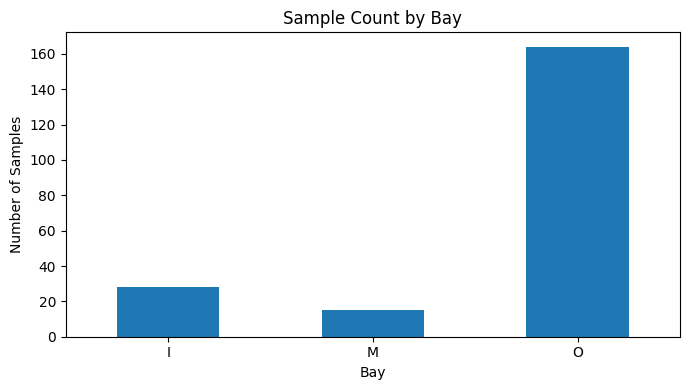

<Figure size 800x500 with 0 Axes>

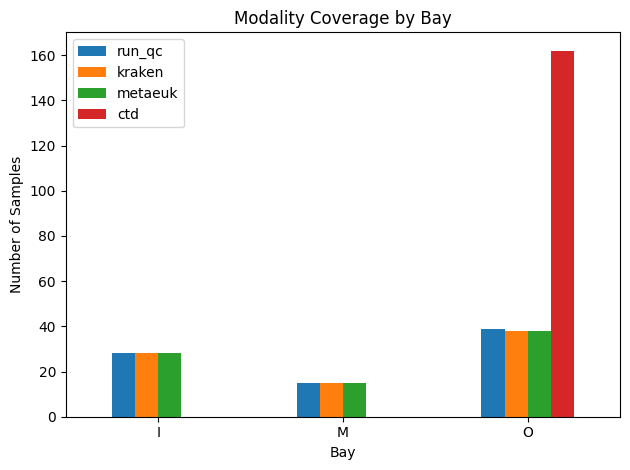

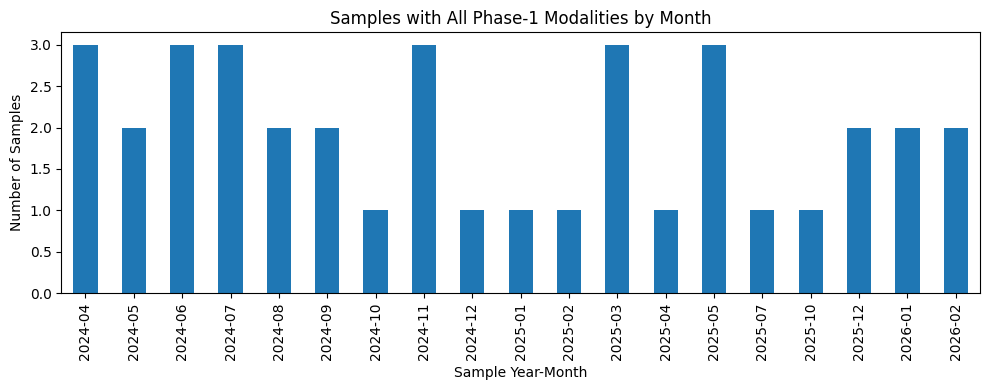

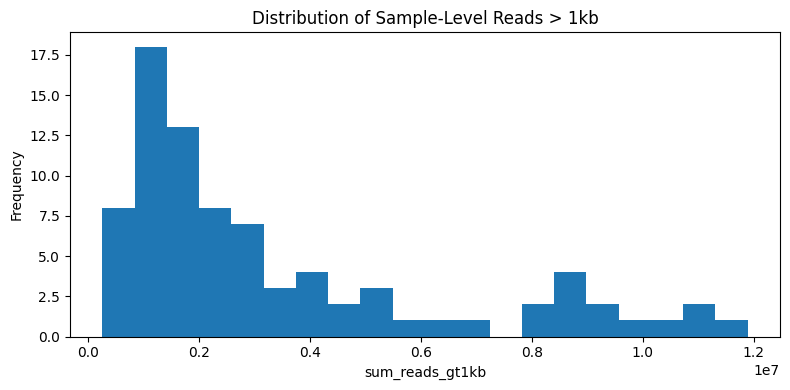


Saved summary CSVs to: /Users/jaronchai/PycharmProjects/anemone-chat/notebooks/data/serving/summary_exports


In [42]:
import matplotlib.pyplot as plt

def _safe_shape(df):
    return df.shape if df is not None else (None, None)

def _exists_df(name):
    return name in globals() and globals()[name] is not None

# -----------------------------
# 1) Input summary
# -----------------------------
input_rows = []

if _exists_df("runid"):
    input_rows.append({
        "input_name": "runid.tsv",
        "loaded_as": "runid",
        "role": "Run-to-sample mapping",
        "rows": runid.shape[0],
        "cols": runid.shape[1],
        "key_columns": "run_id, sample_replicate, sample_id, run_date",
        "main_processing": "Assigned headers, parsed canonical sample_id from sample_replicate",
        "output_tables": "run_qc, sample_qc, sample_registry",
    })

if _exists_df("read_summary"):
    input_rows.append({
        "input_name": "01.read_summary_gt1kb.tsv",
        "loaded_as": "read_summary",
        "role": "Sequencing depth / QC summary",
        "rows": read_summary.shape[0],
        "cols": read_summary.shape[1],
        "key_columns": "sample_replicate, n_reads_gt1kb, bases_gt1kb, n_reads_gt10kb, bases_gt10kb",
        "main_processing": "Assigned headers, numeric casting, joined to runid",
        "output_tables": "run_qc, sample_qc",
    })

if _exists_df("ctd"):
    input_rows.append({
        "input_name": "CTD_Onagawa.tsv",
        "loaded_as": "ctd / ctd_norm / ctd_std",
        "role": "Environmental profile data for Onagawa samples",
        "rows": ctd.shape[0],
        "cols": ctd.shape[1],
        "key_columns": "label/sample_id, ctd_date, depth, environmental variables",
        "main_processing": "Standardized keys and variable names, created profile + sample-level summary",
        "output_tables": "ctd_profile, ctd_summary, sample_registry, sample_multisource_context",
    })

if _exists_df("kraken_genus_wide"):
    input_rows.append({
        "input_name": "Kraken.genus-sample.tsv",
        "loaded_as": "kraken_genus_wide / kraken_genus_long",
        "role": "Kraken sample-by-genus abundance matrix",
        "rows": kraken_genus_wide.shape[0],
        "cols": kraken_genus_wide.shape[1],
        "key_columns": "genus + sample_id columns",
        "main_processing": "Renamed genus column, numeric casting, wide-to-long reshape",
        "output_tables": "kraken_genus_abundance, kraken_genus_enriched, sample_multisource_context",
    })

if _exists_df("metaeuk_genus_wide"):
    input_rows.append({
        "input_name": "MetaEuk.genus-sample.tsv",
        "loaded_as": "metaeuk_genus_wide / metaeuk_genus_long",
        "role": "MetaEuk sample-by-genus abundance matrix",
        "rows": metaeuk_genus_wide.shape[0],
        "cols": metaeuk_genus_wide.shape[1],
        "key_columns": "genus + sample_id columns",
        "main_processing": "Renamed genus column, numeric casting, wide-to-long reshape",
        "output_tables": "metaeuk_genus_abundance, metaeuk_genus_enriched, sample_multisource_context",
    })

if _exists_df("kraken_group_map"):
    input_rows.append({
        "input_name": "Kraken.genus-group.tsv",
        "loaded_as": "kraken_group_map",
        "role": "Kraken genus-to-upper-group mapping",
        "rows": kraken_group_map.shape[0],
        "cols": kraken_group_map.shape[1],
        "key_columns": "genus, upper_group_label",
        "main_processing": "Parsed into genus/group dictionary for Kraken enrichment",
        "output_tables": "kraken_genus_enriched",
    })

if _exists_df("global_group_map"):
    input_rows.append({
        "input_name": "genus-group.tsv",
        "loaded_as": "global_group_map",
        "role": "Global genus-to-upper-group mapping",
        "rows": global_group_map.shape[0],
        "cols": global_group_map.shape[1],
        "key_columns": "genus, upper_group_label",
        "main_processing": "Parsed into broad genus/group dictionary for MetaEuk enrichment",
        "output_tables": "metaeuk_genus_enriched",
    })

if _exists_df("kraken_upper_group_wide"):
    input_rows.append({
        "input_name": "Kraken.upper_group-sample.txt",
        "loaded_as": "kraken_upper_group_wide / kraken_upper_group_long",
        "role": "Kraken upper-group abundance matrix",
        "rows": kraken_upper_group_wide.shape[0],
        "cols": kraken_upper_group_wide.shape[1],
        "key_columns": "upper_group, upper_group_label + sample_id columns",
        "main_processing": "Assigned headers and reshaped to long format",
        "output_tables": "kraken_upper_group_abundance, sample_multisource_context",
    })

if _exists_df("gn_consistency"):
    input_rows.append({
        "input_name": "gn.consistency.tsv",
        "loaded_as": "gn_consistency",
        "role": "Genus-level cross-method consistency",
        "rows": gn_consistency.shape[0],
        "cols": gn_consistency.shape[1],
        "key_columns": "genus, consistency_level",
        "main_processing": "Assigned schema and merged into enriched genus tables",
        "output_tables": "kraken_genus_enriched, metaeuk_genus_enriched",
    })

if _exists_df("km_consistency"):
    input_rows.append({
        "input_name": "km.consistency.tsv",
        "loaded_as": "km_consistency",
        "role": "Contig-level consistency/provenance",
        "rows": km_consistency.shape[0],
        "cols": km_consistency.shape[1],
        "key_columns": "contig_id, method_code, consistency_level",
        "main_processing": "Assigned schema and stored for later provenance-heavy use",
        "output_tables": "contig_consistency",
    })

input_summary = pd.DataFrame(input_rows)

# -----------------------------
# 2) Step summary
# -----------------------------
process_steps = pd.DataFrame([
    {
        "step_no": 1,
        "step_name": "Raw inventory and schema inspection",
        "purpose": "Verify file presence, rough shape, and which files need manual headers",
        "main_artifacts": "ctd_inventory, meta_inventory",
    },
    {
        "step_no": 2,
        "step_name": "Canonical sample key parsing",
        "purpose": "Standardize sample_replicate -> sample_id, bay, station_code, year_month",
        "main_artifacts": "parse_sample_replicate(), add_sample_parsed_columns()",
    },
    {
        "step_no": 3,
        "step_name": "Run/QC normalization",
        "purpose": "Join run-level metadata with sequencing QC and aggregate to sample level",
        "main_artifacts": "run_qc, sample_qc",
    },
    {
        "step_no": 4,
        "step_name": "CTD normalization",
        "purpose": "Standardize CTD keys and environmental variable names",
        "main_artifacts": "ctd_norm, ctd_std",
    },
    {
        "step_no": 5,
        "step_name": "CTD feature summarization",
        "purpose": "Reduce depth profiles into sample-level environmental summaries",
        "main_artifacts": "ctd_summary",
    },
    {
        "step_no": 6,
        "step_name": "Metagenome matrix reshaping",
        "purpose": "Convert wide sample-by-genus matrices into long tables for querying and joins",
        "main_artifacts": "kraken_genus_long, metaeuk_genus_long",
    },
    {
        "step_no": 7,
        "step_name": "Taxonomy/group enrichment",
        "purpose": "Attach upper-group mappings and consistency scores to taxa",
        "main_artifacts": "kraken_genus_enriched, metaeuk_genus_enriched",
    },
    {
        "step_no": 8,
        "step_name": "Serving-layer assembly",
        "purpose": "Build sample-centric tables for downstream retrieval and LLM grounding",
        "main_artifacts": "sample_registry, sample_multisource_context",
    },
    {
        "step_no": 9,
        "step_name": "Validation",
        "purpose": "Check uniqueness, coverage, missingness, date mismatches, mapping gaps, and numeric sanity",
        "main_artifacts": "validation_report",
    },
])

# -----------------------------
# 3) Output summary
# -----------------------------
output_rows = []

for name in [
    "run_qc",
    "sample_qc",
    "ctd_std",
    "ctd_summary",
    "kraken_genus_long",
    "metaeuk_genus_long",
    "kraken_genus_enriched",
    "metaeuk_genus_enriched",
    "kraken_upper_group_long",
    "sample_registry",
    "sample_multisource_context",
    "validation_report",
]:
    if _exists_df(name):
        df = globals()[name]
        output_rows.append({
            "table_name": name,
            "rows": df.shape[0],
            "cols": df.shape[1],
        })

output_summary = pd.DataFrame(output_rows)

# -----------------------------
# 4) Narrative summary
# -----------------------------
print("=" * 88)
print("PHASE-1 MULTISOURCE PREPROCESSING SUMMARY")
print("=" * 88)

print("\nWhat we started with")
print("- Raw CTD profile data for Onagawa")
print("- Raw metagenomic abundance matrices for Kraken and MetaEuk")
print("- Run-level mapping and sequencing QC summaries")
print("- Taxonomy grouping dictionaries")
print("- Genus-level and contig-level consistency tables")

print("\nWhat we did")
print("- Standardized sample identifiers into a canonical sample_id")
print("- Joined sequencing run metadata to QC summaries")
print("- Standardized CTD fields and derived sample-level environmental summaries")
print("- Reshaped wide metagenomic matrices into long queryable tables")
print("- Attached taxonomy-group mappings and genus-level consistency metadata")
print("- Built serving-layer sample-centric tables for LLM grounding")
print("- Ran validation checks on keys, missingness, date mismatches, and mapping coverage")

print("\nWhat we have now")
print("- Normalized tables for QC, CTD, Kraken, MetaEuk, and taxonomy/group metadata")
print("- A sample registry describing modality availability and join status")
print("- A sample_multisource_context serving table for retrieval and prompt assembly")
print("- A validation report capturing PASS/WARN conditions")

print("\nInput summary")
display(input_summary)

print("\nProcessing steps")
display(process_steps)

print("\nOutput summary")
display(output_summary)

# -----------------------------
# 5) Quick coverage tables
# -----------------------------
if "sample_registry" in globals():
    registry_quick = pd.DataFrame({
        "metric": [
            "total_samples",
            "samples_with_run_qc",
            "samples_with_kraken",
            "samples_with_metaeuk",
            "samples_with_ctd",
            "samples_with_all_phase1_modalities",
        ],
        "value": [
            len(sample_registry),
            int(sample_registry["has_run_qc"].sum()),
            int(sample_registry["has_kraken"].sum()),
            int(sample_registry["has_metaeuk"].sum()),
            int(sample_registry["has_ctd"].sum()),
            int((
                sample_registry["has_run_qc"]
                & sample_registry["has_kraken"]
                & sample_registry["has_metaeuk"]
                & sample_registry["has_ctd"]
            ).sum()),
        ]
    })
    print("\nQuick registry summary")
    display(registry_quick)

# -----------------------------
# 6) Plots
# -----------------------------

# Plot 1: sample counts by bay
if "sample_registry" in globals():
    bay_counts = (
        sample_registry["bay"]
        .fillna("NA")
        .value_counts()
        .sort_index()
    )

    plt.figure(figsize=(7, 4))
    bay_counts.plot(kind="bar")
    plt.title("Sample Count by Bay")
    plt.xlabel("Bay")
    plt.ylabel("Number of Samples")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Plot 2: modality coverage by bay
if "sample_registry" in globals():
    cov_by_bay = (
        sample_registry.groupby("bay", dropna=False)
        .agg(
            run_qc=("has_run_qc", "sum"),
            kraken=("has_kraken", "sum"),
            metaeuk=("has_metaeuk", "sum"),
            ctd=("has_ctd", "sum"),
        )
        .fillna(0)
        .astype(int)
    )

    plt.figure(figsize=(8, 5))
    cov_by_bay.plot(kind="bar")
    plt.title("Modality Coverage by Bay")
    plt.xlabel("Bay")
    plt.ylabel("Number of Samples")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Plot 3: all-modalities sample counts by month
if "sample_registry" in globals():
    phase1_ready = sample_registry.loc[
        sample_registry["has_run_qc"]
        & sample_registry["has_kraken"]
        & sample_registry["has_metaeuk"]
        & sample_registry["has_ctd"]
    ].copy()

    month_counts = (
        phase1_ready["sample_year_month"]
        .fillna("NA")
        .value_counts()
        .sort_index()
    )

    plt.figure(figsize=(10, 4))
    month_counts.plot(kind="bar")
    plt.title("Samples with All Phase-1 Modalities by Month")
    plt.xlabel("Sample Year-Month")
    plt.ylabel("Number of Samples")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

# Plot 4: sequencing depth distribution
if "sample_qc" in globals():
    plt.figure(figsize=(8, 4))
    sample_qc["sum_reads_gt1kb"].dropna().plot(kind="hist", bins=20)
    plt.title("Distribution of Sample-Level Reads > 1kb")
    plt.xlabel("sum_reads_gt1kb")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 7) Optional: save summary tables
# -----------------------------
summary_dir = SERVING_DIR / "summary_exports"
summary_dir.mkdir(parents=True, exist_ok=True)

input_summary.to_csv(summary_dir / "input_summary.csv", index=False)
process_steps.to_csv(summary_dir / "process_steps.csv", index=False)
output_summary.to_csv(summary_dir / "output_summary.csv", index=False)

print(f"\nSaved summary CSVs to: {summary_dir}")

# PoC

In [47]:
import json
from urllib.request import Request, urlopen

OLLAMA_URL = "http://localhost:11434/api/chat"
MODEL = "qwen2.5:14b-instruct"

# -----------------------------
# Pick one phase-1-ready sample
# -----------------------------
candidate_samples = (
    sample_registry.loc[
        sample_registry["has_run_qc"]
        & sample_registry["has_kraken"]
        & sample_registry["has_metaeuk"]
        & sample_registry["has_ctd"],
        "sample_id"
    ]
    .sort_values()
    .tolist()
)

if not candidate_samples:
    raise ValueError("No sample found with run_qc + kraken + metaeuk + ctd.")

SAMPLE_ID = candidate_samples[0]

row = sample_multisource_context.loc[sample_multisource_context["sample_id"] == SAMPLE_ID]
if row.empty:
    raise ValueError(f"Sample {SAMPLE_ID} not found in sample_multisource_context.")

row = row.iloc[0]

def safe_json_loads(x):
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return []
    if isinstance(x, str) and x.strip():
        try:
            return json.loads(x)
        except Exception:
            return []
    return []

# Be robust to merged-column naming
def pick_first_existing(series, candidates):
    for c in candidates:
        if c in series.index:
            return series.get(c)
    return None

kraken_top_genera_json = safe_json_loads(
    pick_first_existing(row, ["top_genus_10_json"])
)

metaeuk_top_genera_json = safe_json_loads(
    pick_first_existing(row, ["top_genus_10_json_y", "top_genus_10_json_metaeuk"])
)

upper_group_json = safe_json_loads(
    pick_first_existing(row, ["top_upper_group_10_json"])
)

context_payload = {
    "sample_id": row.get("sample_id"),
    "sample_year_month": row.get("sample_year_month"),
    "bay": row.get("bay"),
    "station_code": row.get("station_code"),
    "ctd_date": str(row.get("ctd_date")) if pd.notna(row.get("ctd_date")) else None,
    "sampling_coverage": {
        "has_run_qc": bool(row.get("has_run_qc")) if pd.notna(row.get("has_run_qc")) else None,
        "has_kraken": bool(row.get("has_kraken")) if pd.notna(row.get("has_kraken")) else None,
        "has_metaeuk": bool(row.get("has_metaeuk")) if pd.notna(row.get("has_metaeuk")) else None,
        "has_ctd": bool(row.get("has_ctd")) if pd.notna(row.get("has_ctd")) else None,
        "n_runs": row.get("n_runs"),
        "sum_reads_gt1kb": row.get("sum_reads_gt1kb"),
        "sum_bases_gt1kb": row.get("sum_bases_gt1kb"),
        "n_depth_points": row.get("n_depth_points"),
        "min_depth_m": row.get("min_depth_m"),
        "max_depth_m": row.get("max_depth_m"),
    },
    "environment_summary": {
        "surface_temperature": row.get("surface_temperature"),
        "bottom_temperature": row.get("bottom_temperature"),
        "mean_temperature": row.get("mean_temperature"),
        "surface_salinity": row.get("surface_salinity"),
        "bottom_salinity": row.get("bottom_salinity"),
        "mean_salinity": row.get("mean_salinity"),
        "max_chl_a": row.get("max_chl_a"),
        "mean_chl_a": row.get("mean_chl_a"),
        "min_do_mg_l": row.get("min_do_mg_l"),
        "mean_do_mg_l": row.get("mean_do_mg_l"),
        "max_turbidity": row.get("max_turbidity"),
    },
    "biology_summary": {
        "kraken_top_genera": kraken_top_genera_json,
        "metaeuk_top_genera": metaeuk_top_genera_json,
        "kraken_top_upper_groups": upper_group_json,
    },
    "basis_of_data": [
        "sample_multisource_context",
        "sample_registry",
        "ctd_summary",
        "sample_qc",
        "Kraken top genera summary",
        "MetaEuk top genera summary",
        "Kraken upper-group summary",
        "genus consistency where available",
    ],
}

# More natural researcher-style question
QUESTION = (
    f"For this Onagawa sample ({SAMPLE_ID}), what kind of water conditions did we have, "
    f"what organisms seem to stand out, and is there anything I should be careful not to "
    f"over-interpret from this result?"
)

system_prompt = """You are assisting marine and fisheries researchers who may not be technical.
Use only the structured evidence provided.
Explain in plain scientific language.
Do not invent missing values.
Do not claim certainty when evidence is limited.
When appropriate, distinguish between:
1) what the data suggests,
2) what is uncertain,
3) what would need more data to confirm."""

user_prompt = f"""
Question from researcher:
{QUESTION}

Structured evidence:
{json.dumps(context_payload, ensure_ascii=False, indent=2, default=str)}

Please answer in this format:

1. Short interpretation
2. Water conditions
3. Organisms that stand out
4. Cautions / uncertainty
5. Basis of answer

Requirements:
- Write as if speaking to a fisheries or marine field researcher.
- Avoid technical AI or database jargon.
- Mention missingness or uncertainty if relevant.
- In "Basis of answer", briefly state that the answer is based on processed CTD, Kraken, MetaEuk, QC, and taxonomy summary data for this sample.
- Keep the total answer reasonably concise.
"""

payload = {
    "model": MODEL,
    "messages": [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ],
    "stream": False,
    "options": {
        "temperature": 0.0,
        "top_p": 0.9,
        "num_ctx": 8192,
    },
}

req = Request(
    OLLAMA_URL,
    data=json.dumps(payload).encode("utf-8"),
    headers={"Content-Type": "application/json"},
    method="POST",
)

with urlopen(req, timeout=300) as resp:
    result = json.loads(resp.read().decode("utf-8"))

answer = result["message"]["content"]

print("=== SAMPLE_ID ===")
print(SAMPLE_ID)

print("\n=== RESEARCHER-STYLE QUESTION ===")
print(QUESTION)

print("\n=== STRUCTURED BASIS ===")
for item in context_payload["basis_of_data"]:
    print("-", item)

print("\n=== ANSWER ===")
print(answer)

=== SAMPLE_ID ===
2024-04-O-s1

=== RESEARCHER-STYLE QUESTION ===
For this Onagawa sample (2024-04-O-s1), what kind of water conditions did we have, what organisms seem to stand out, and is there anything I should be careful not to over-interpret from this result?

=== STRUCTURED BASIS ===
- sample_multisource_context
- sample_registry
- ctd_summary
- sample_qc
- Kraken top genera summary
- MetaEuk top genera summary
- Kraken upper-group summary
- genus consistency where available

=== ANSWER ===
1. **Short interpretation**: The Onagawa sample (2024-04-O-s1) was taken in April 2024 from station s1 with comprehensive water quality measurements and biological analysis, showing a diverse community of organisms but some inconsistencies in taxonomic data.

2. **Water conditions**:
   - **Temperature**: The mean temperature ranged between 13.9°C at the bottom and 15.7°C at the surface, averaging around 14.9°C.
   - **Salinity**: Salinity varied from 33.2 PSU at the surface to 34.2 PSU at the